# Probabilistic reasoning

Agents operating in the real world must **handle uncertainty**, whether due to **partial observability**, **nondeterministic outcomes**, or **adversarial conditions**. An agent often does not know exactly what state it is in or where it will end up after acting. We have seen that planning can address uncertainty through contingency plans that cover every possible sensor report. While this works for simple problems, it has major drawbacks: the agent must track all possible explanations, no matter how unlikely, which creates large belief states; complete contingent plans can grow arbitrarily large; and sometimes no plan can guarantee goal achievement, yet the agent must still act. Consider a weather forecasting system. It aims to predict whether it will rain tomorrow to help farmers decide whether to irrigate their crops. A purely logical approach might try to write rules like:

But this is not always true, dark clouds do not guarantee rain. So the rule expands:

To make the rule exceptionless, we’d have to add endless possibilities.Alternatively, we could flip the rule:

But rain can occur without visible dark clouds in the forecast area. To make this logically perfect, we’d have to list every factor that affects rainfall: humidity, wind patterns, pressure systems, terrain features, and so on. 

The connection between dark clouds and rain **is not a strict logical consequence in either direction**. This is typical of many other real-world domains like medicine, law, business, design, or even everyday decisions. Using only strict logic for forecasting breaks down for three main reasons:
- **Laziness**: it’s infeasible to list every condition that affects the outcome
- **Theoretical ignorance**: our understanding of complex weather systems is incomplete
- **Practical ignorance**: even with good models, we rarely have perfect, up-to-the-minute data for every variable.

An agent’s knowledge can usually provide only a **degree of belie**f in relevant statements, not absolute certainty. The main tool for representing and reasoning with degrees of belief is **probability theory**. Logic and probability share **the same ontological view**: the world consists of facts that either hold or do not in any given situation. But they d**iffer in their epistemological commitments**: a logical agent considers each statement true, false, or unknown, while a probabilistic agent assigns a numerical degree of belief between 0 (certainly false) and 1 (certainly true). 

Probability theory lets us **summarize the uncertainty** that arises from our laziness (it’s infeasible to model every detail) and ignorance (we don’t fully understand or observe every factor): we cannot list every possible condition that affects whether dark clouds will bring rain, but we can express our uncertainty quantitatively. For example, the weather forecaster might estimate that there is a 70% chance (probability 0.7) of rain tomorrow if dark clouds are forming now. Such beliefs can be **based on statistical data** (historical weather patterns), meteorological **models**, or a **combination of evidence sources**.

Consider again the farmer deciding whether to irrigate when there is a 70% chance of rain tomorrow. Is it rational for the farmer to skip irrigation, trusting the forecast? Not necessarily. If missing the irrigation would critically damage the crops, it may be worth accepting the extra cost or effort of watering the field anyway. To make good decisions under uncertainty, an agent needs to weigh not just the probabilities but also its **preferences** over the possible outcomes. An outcome is a fully specified state of the world, including factors like whether the crops get enough water and whether unnecessary irrigation costs are avoided. 

**Utility theory** says that every possible outcome has a degree of usefulness, or utility, for an agent. It is is subjective: it depends on the agent’s goals and preferences. For example, if a forecast predicts a 70% chance of rain, a farmer’s utility for crops get enough water naturally may be high, but the risk of losing a harvest if it doesn’t rain may make irrigation worthwhile 

**Decision theory** combines probabilities (from probability theory) with these preferences (from utility theory). The farmer then makes a decision (whether to irrigate or not) based onexpected utility: balancing the cost of irrigation against the risk of crops drying out if the forecast is wrong. This is the essence of **maximum expected utility (MEU)**:  making rational decisions under uncertainty by estimating the likelihood of different outcomes and choosing actions that maximize expected utility. The following Python code implements a simple agent that maintains a probabilistic belief state, updates its beliefs based on percepts and actions, estimates the expected utility of possible actions, and selects the action that maximizes expected utility:

In [1]:
class DecisionTheoreticAgent:
    def __init__(self, initial_belief_state, action_model, utility_function):
        self.belief_state = initial_belief_state
        self.action_model = action_model
        self.utility_function = utility_function
        self.last_action = None

    # Update the belief state based on the last action taken and the new percept.
    # This should use probabilistic inference.
    def update_belief_state(self, action, percept):
        self.belief_state = self.action_model.update_belief(self.belief_state, action, percept)

    # Calculate expected utilities for each possible action.
    def calculate_expected_utilities(self):
        expected_utilities = {}
        for action in self.action_model.available_actions():
            outcome_probs = self.action_model.outcome_probabilities(self.belief_state, action)
            expected_utility = sum(
                prob * self.utility_function(state)
                for state, prob in outcome_probs.items()
            )
            expected_utilities[action] = expected_utility
        return expected_utilities

    # Select the action with the highest expected utility.
    def select_action(self, expected_utilities):
        return max(expected_utilities, key=expected_utilities.get)

    # The main agent function: update belief state, compute expected utilities, 
    # select action.
    def perceive_and_act(self, percept):
        self.update_belief_state(self.last_action, percept)
        expected_utilities = self.calculate_expected_utilities()
        action = self.select_action(expected_utilities)
        self.last_action = action
        return action

The agent’s belief state represents not just the possibilities for world states but also their probabilities. Given the belief state and some knowledge of the effects of actions, the agent can make probabilistic predictions of action outcomes and hence select the action with the highest expected utility.

## Probability Theory

Like logical assertions, **probabilistic assertions** describe possible worlds. In logic, an assertion rules out all possible worlds in which the statement is false. In probability theory, assertions go further by describing **how likely each possible world is**. In probability theory, the complete set of possible worlds is called the **sample space** (W). These worlds are **mutually exclusive** and **exhaustive**: no two can occur at the same time, and one of them must occur. For example, when rolling two dice, the sample space consists of 36 possible outcomes:

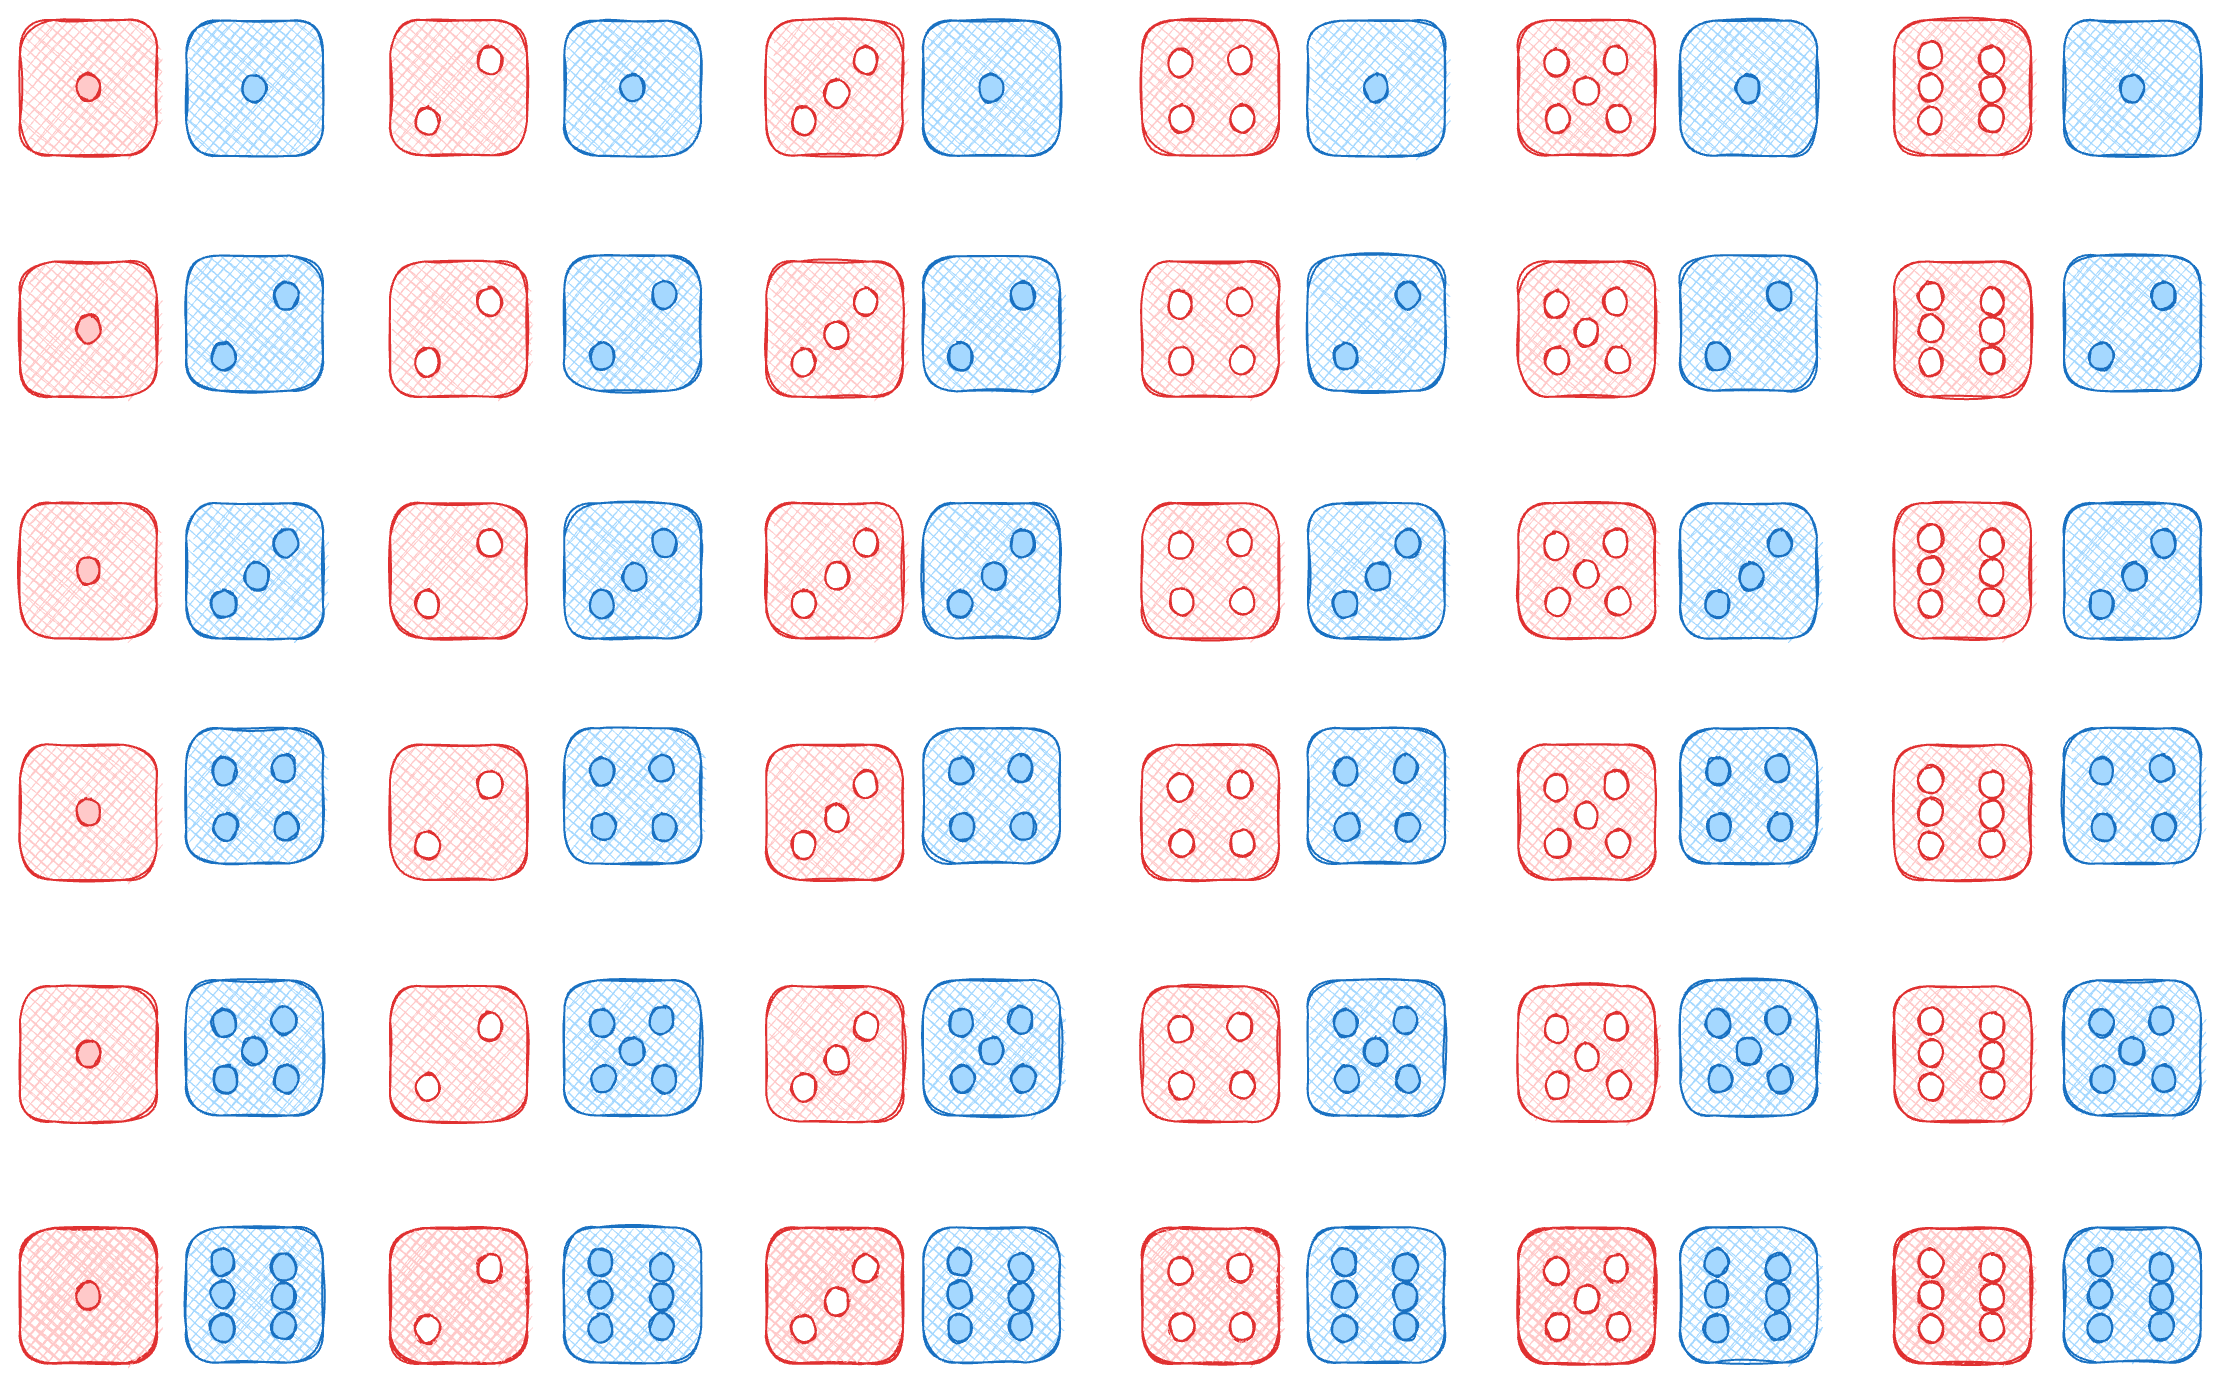

A fully defined probability model assigns a numerical probability to each possible world (w). The basic axioms of probability theory say that every possible world has a probability between 0 and 1 and that the total probability of the set of possible worlds is 1:

$\displaystyle 0 < P(w) < 1$

$\displaystyle \sum_{w \in W} P(w) = 1$

For example, if we assume that each die is fair and the rolls don’t interfere with each other, then each of the possible worlds has probability 1/36. If the dice are loaded then some worlds will have higher probabilities and some lower, but they will all still sum to 1.

### Random variables

In probability theory, variables are called **random variables**. A random variable is **a function that maps each possible world to a value in some specified range**, the set of values the variable can take on. For example, the total sum of two dice rolls can be represented by a random variable called Total, which maps each possible world to the sum of the two dice. The range of Total is:

$\displaystyle \{2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12\}$

Another random variable might be Die1, which maps each possible world to the value shown by the first die. The range of Die1 is:

$\displaystyle \{1, 2, 3, 4, 5, 6\}$

By convention, we write the names of random variables in uppercase (e.g., Total, Die1) and use lowercase letters for specific values they may take. For instance, we write:

P(X = x)

to denote the probability that the random variable X takes on the value x.

Ranges can include any kind of values. For example, a Boolean random variable has the range {True, False}. Variables can have infinite ranges, either discrete or continuous.

### Unconditional probabilities (priors)

Probabilistic assertions and queries usually refer not to individual possible worlds, but to **sets of possible worlds**. For example, when rolling two dice, we might ask for the probability that the total is 11, or that doubles are rolled. In probability theory, such sets are called **events**; in logic, a set of worlds corresponds to a **proposition**. In this sense, “event” and “proposition” mean roughly the same thing. The probability of a proposition x is defined as **the sum of the probabilities of all the possible worlds in which that proposition holds**:

$\displaystyle P(x) = \sum_{w \in x} P(w)$ 

For example, when rolling fair dice, the probaility of having a sum of 11 is:

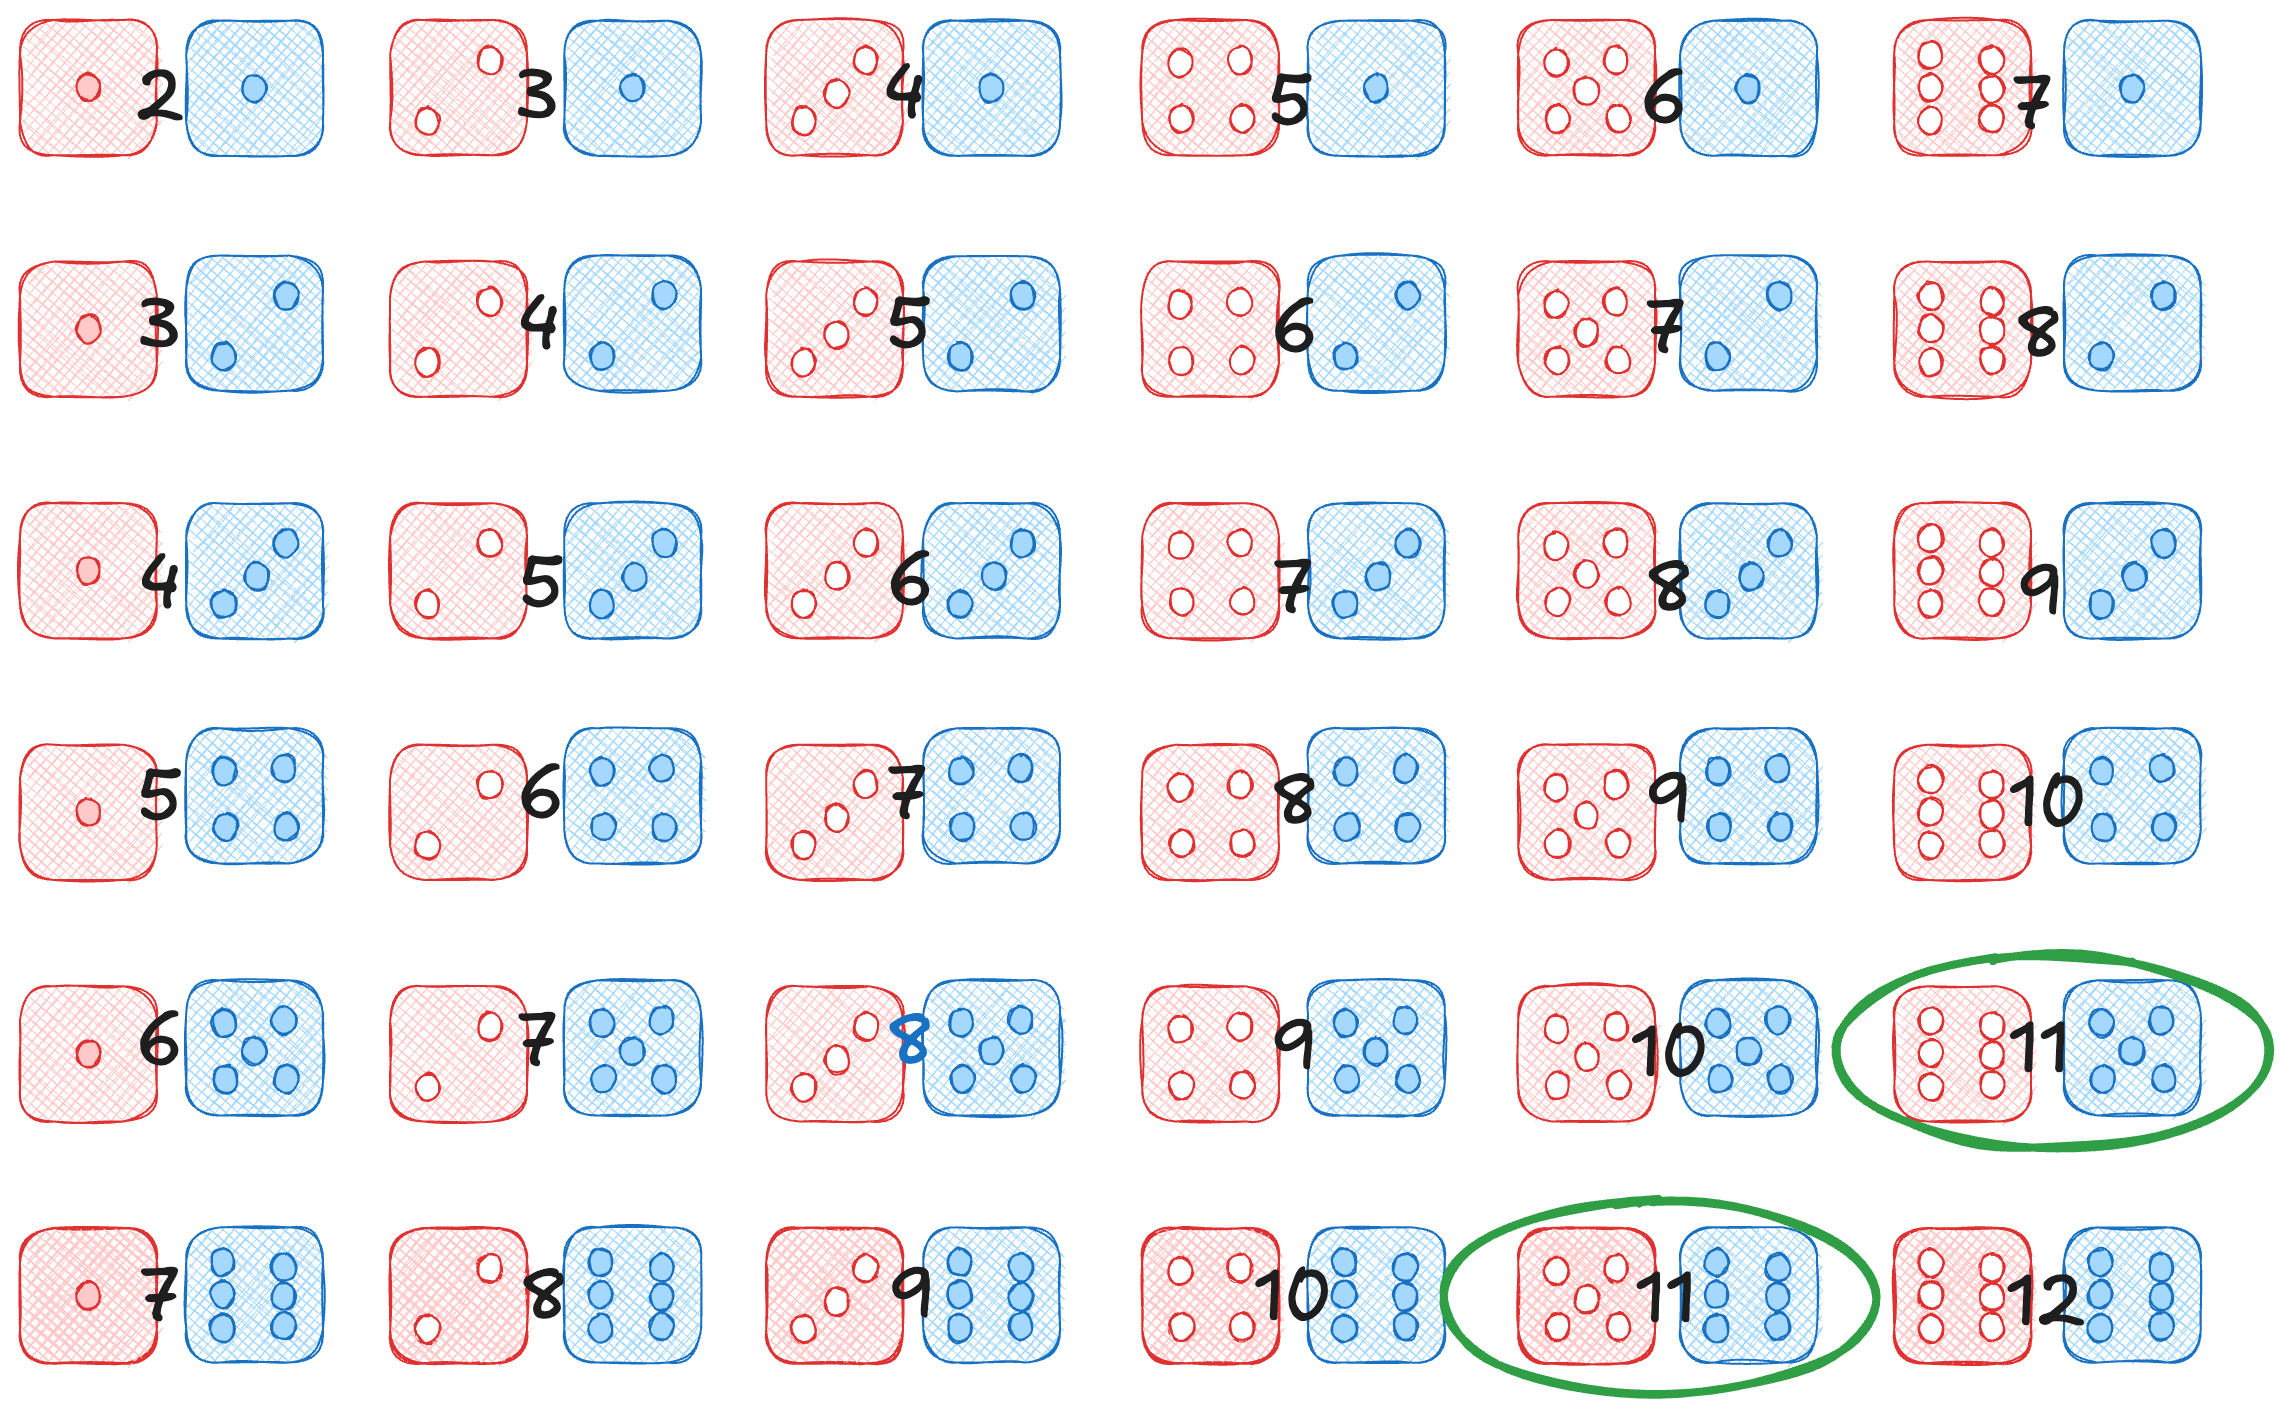

In [2]:
# Each outcome (die1, die2) has probability 1/36 for fair dice
p_single_outcome = 1 / 36

# Total = 11 can come from two outcomes: (5,6) and (6,5)
p_total_11 = p_single_outcome + p_single_outcome

print(f"P(Total = 11) = {p_total_11} = {1/18}")

P(Total = 11) = 0.05555555555555555 = 0.05555555555555555


Probabilities like this is called **unconditional or prior probabilities**, since they express degrees of belief in propositions **before any additional information** is known. Note that probability theory does not require us to know the probability of every individual possible world. For example, if we believe that two dice are biased to roll the same number, we might assert that P(doubles) = 1/4 without needing to know whether doubles of sixes are more likely than doubles of twos. Just like logical statements, such an assertion constrains the underlying probability model but does not fully specify it. 

### Conditional probablities (posteriors)

Most of the time, however, we have some information (called **evidence**) that has already been observed. For example, if the first die has landed on a 5 and we’re waiting to see the second die, we no longer care about the unconditional probability of rolling doubles. Instead, we want the **conditional or posterior probability** of rolling doubles given that the first die shows a 5, written as:

$\displaystyle P(Doubles = true \,|\, Die1 = 5)$

Similarly, suppose the prior probability of rain tomorrow is:

$\displaystyle P(Whether = rain) = 0.2$


based on long-term climate data. But if we see dark clouds gathering in the sky, what really matters is the conditional probability:

$\displaystyle P(Wheter = rain \,|\, DarkClouds = true) = 0.6$

This **new evidence updates our belief** about the chance of rain, helping us make better decisions under uncertainty. It’s important to understand that the unconditional probability remains valid even after observing new evidence, it just isn’t particularly useful on its own. For example, the general probability of rain today, say P(rain) = 0.2, is still true. But once we observe the dark clouds overhead, we should condition our belief on that new evidence. An intelligent agent must always **base its decisions on all the evidence** it has observed so far.

It’s also important to distinguish conditioning from logical implication. Saying that the probability of rain given dark clouds is 0.6 does not mean "whenever there are dark clouds, it rains with probability 0.6". Rather, it means "if we see dark clouds **and have no additional information**, then the probability of rain is 0.6". That extra clause is critical. For instance, if we also learn that the weather radar shows clear skies beyond the clouds, we certainly wouldn’t still believe the chance of rain is 0.6, we would instead use:

$\displaystyle P(Wheter = rain \,|\, DarkClouds = true \, \land \, Radar = clear) = 0.1$

Mathematically, a conditional probability is defined in terms of unconditional probabilities as follows. Given two propositions A and B, the conditional probability of A given B is defined as:

$\displaystyle P(A|B) = \frac{P(A \land B)}{P(B)}$

This definition makes sense if we remember that observing some evidence b effectively rules out all possible worlds where b is false, leaving only the worlds where b is true. The total probability of these remaining worlds is:

$\displaystyle P(B)$

Within this reduced set, the worlds where another proposition a is true must satisfy:

$\displaystyle A \land B$

For example, if we want to know the probability of the sum of two dice being 9 given that the first die shows a 6:

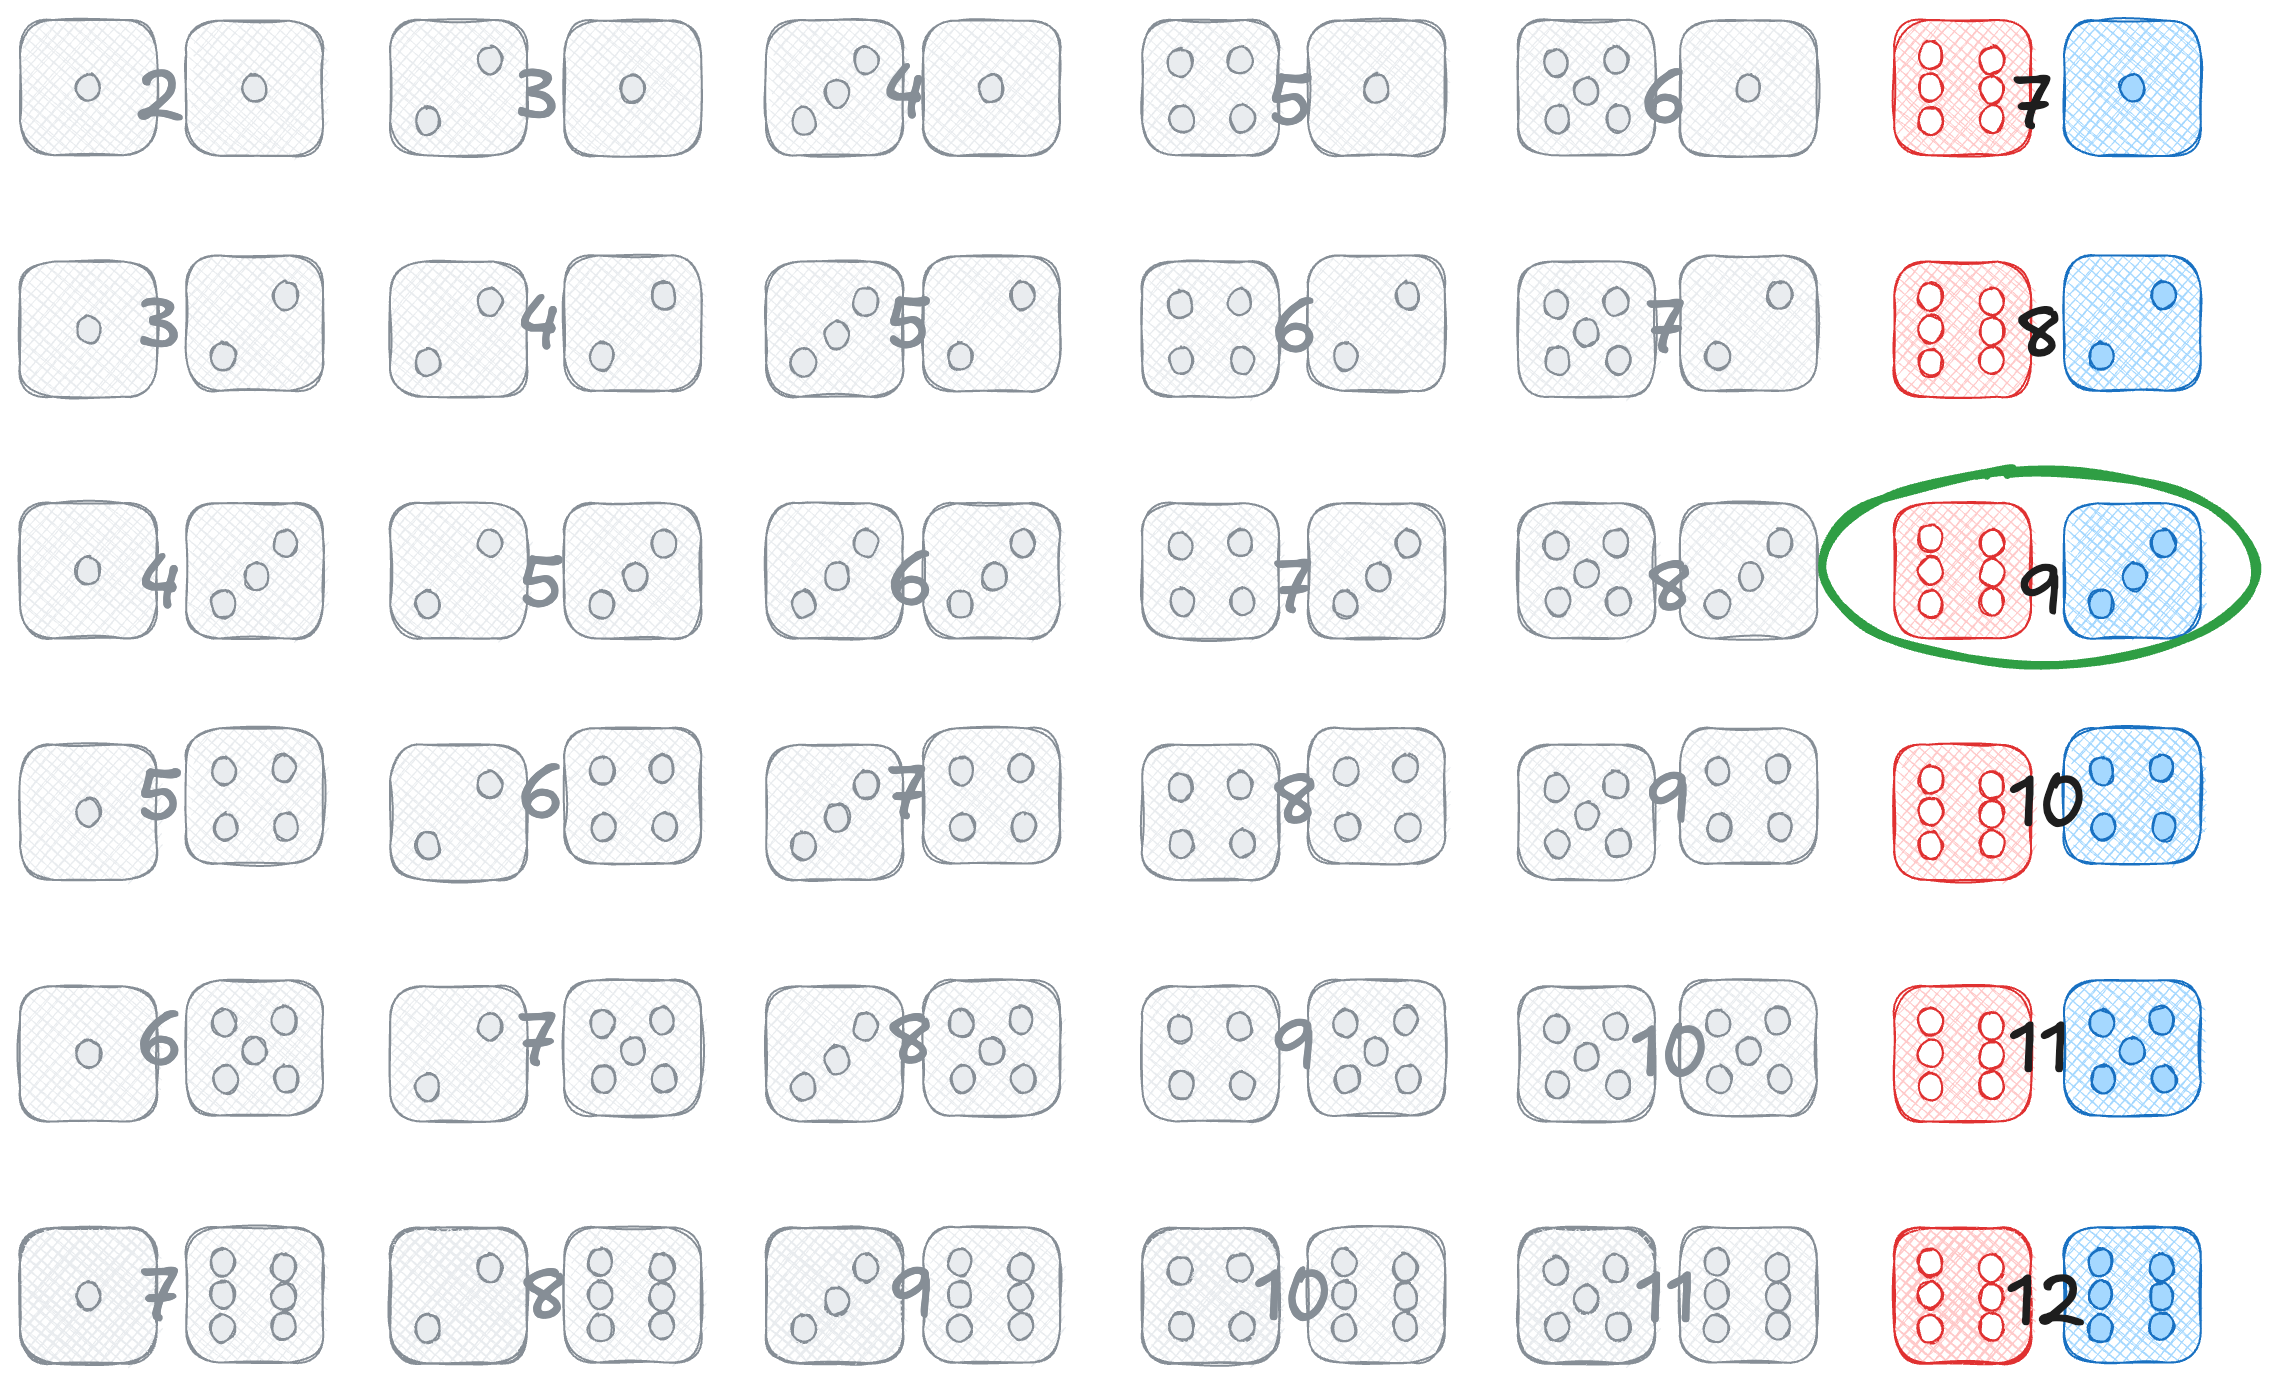

The worlds where the first die is 6 are only those of the last column, and among those, the worlds where the sum is 9 is only the one where the second die is 3. So we have:

$\displaystyle P(Sum = 9 \,|\, Die1 = 6) = \frac{P(Sum = 9 \land Die1 = 6)}{P(Die1 = 6)} = \frac{1/36}{6/36} = \frac{1}{6}$

The definition of conditional probability can be rearranged into a more convenient form known as the **product rule**:

$\displaystyle P(A \land B) = P(A | B) P(B)$

The product rule is often easier to remember: it simply says that the probability of both a and b being true is equal to the probability of b being true, multiplied by the probability that a is true given b.

### Probability distributions
 
Sometimes we want to describe the probabilities of all possible values that a random variable can take. For example, for a Weather variable we might write:

$\displaystyle P(Weather=sun) = 0.6$        
$\displaystyle P(Weather=rain) = 0.1$       
$\displaystyle P(Weather=cloud) = 0.29$         
$\displaystyle P(Weather=snow) = 0.01$      

As a shorthand, we can represent this as:

$\displaystyle P(Weather) = \{sun: 0.6, rain: 0.1, cloud: 0.29, snow: 0.01\}$

This P statement defines a **probability distribution** for the random variable: it assigns a probability to each possible value in its range. When the range is finite and discrete, as in this example, the distribution is called a **categorical distribution**.

In addition to distributions over single random variables, we can also use distributions involving multiple variables. For example:

$\displaystyle P(Weather, Activity) = \left\{
\begin{array}{c|cc}
\text{Weather} \backslash \text{Activity} & \text{picnic} & \text{study} \\ \hline
\text{sunny} & 0.3 & 0.2 \\
\text{rainy} & 0.05 & 0.25 \\
\text{cloudy} & 0.1 & 0.1 \\
\end{array}
\right\}$   


denotes the **joint probability distribution** of the probabilities of all possible combinations of the values of Weather and Activity random variables, where Weather might take on the values {sunny, rainy, cloudy}, and Activity might be {picnic, study}. The joint probability distribution fully specifies how probability is spread across all combinations of the variables values.

For continuous random variables, we can’t write out the entire distribution as a vector, because there are **infinitely many possible values** and **the probability that the variable takes on any exact value is always zero**. Instead, we define the probability that a random variable takes on a value around some point x using a **probability density function**, which is a function of x.  Intuitively, the probability density at x is defined as the probability that X falls within an arbitrarily small region near x, divided by the width of that region:

$\displaystyle PDF(x) = \lim_{\Delta x \to 0} \frac{P(x \leq X \leq x + \Delta x)}{\Delta x}$

Then we can be interested in the probability that the random variable takes on a value in some interval [a, b]:

$\displaystyle P(a \leq X \leq b) = \int_a^b PDF(x) dx$

However, in the following we will focus on discrete random variables, where the distribution can be represented as a vector of probabilities.

### Independence

Two random variables are said to be **independent** if **knowing the value of one does not change our belief about the other**. In other words, they have **no influence** on each other. Mathematically, this means that the conditional probability of one variable given the other is equal to its unconditional probability:

$\displaystyle P(A \,|\, B) = P(A)$

For example, if we know that the weather is sunny, it does not change our belief about whether the first die will show a 6. In this case, the two random variables Weather and Die1 are independent. We can express independence also in terms of joint probabilities:

$\displaystyle P(A \land B) = P(A) P(B)$

The probability of getting a 6 on the second die is still 1/6, regardless of the value of the first die:

$\displaystyle P(Die2 = 6 \,|\, Die1 = 6) = P(Die2 = 6) = \frac{1}{6}$

And the probability of rolling two sixes is:

$\displaystyle P(Die1 = 6 \land Die2 = 6) = P(Die1 = 6) P(Die2 = 6) = \frac{1}{6} \frac{1}{6} = \frac{1}{36}$

We can have an notion of independence of two variables once we know something about a third variable. This is called **conditional independence**. Two random variables A and B are conditionally independent given a third variable C if:

$\displaystyle P(A, B \,|\, C) = P(A \,|\, C) P(B \,|\, C)$

For example, suppose we’re interested in whether the grass is wet (A), whether the sprinkler was on (B), and whether it rained (C). If we don’t know whether it rained, seeing that the grass is wet makes we suspect the sprinkler was probably on (X and Y are related). But once we know for sure that it rained, whether the sprinkler was on doesn’t add any new information about the wet grass, because the rain alone explains it. In this case, X and Y are conditionally independent given Z.

Conditional independence allows us to **simplify complex probability models** because we can "disconnect" variables when we know **a common cause** or context.

### Bayes' rule

Using the product rule, we can wrote those two equations as:

$\displaystyle P(A \land B) = P(A | B) P(B)$

and 

$\displaystyle P(A \land B) = P(B | A) P(A)$

Equating the two gives us **Bayes' rule**:

$\displaystyle P(A | B) = \frac{P(B | A) P(A)}{P(B)}$

On the surface, Bayes’ rule does not seem very useful, however it is really useful in practice because there are many cases where we do have good probability estimates for the three numbers on the right-hand side of the equation, but we do not have a good estimate for the left-hand side. Often, we perceive as evidence the effect of some unknown cause and we would like to determine that cause. In that case, Bayes’ rule becomes:

$\displaystyle P(\text{cause} | \text{effect}) = \frac{P(\text{effect} | \text{cause}) P(\text{cause})}{P(\text{effect})}$

The first conditional probability quantifies the relationship in the causal direction, whereas the other one describes the diagnostic direction. In a task such as medical diagnosis, we often have conditional probabilities on causal relationships. The doctor knows P(symptoms | disease) and want to derive a diagnosis P(disease | symptoms). For example, a doctor knows that the meningitis causes a patient to have a stiff neck:

$\displaystyle P(\text{StiffNeck} | \text{Meningitis}) = 0.7$

The doctor also knows some unconditional facts: the prior probability that any patient has meningitis and the prior probability that any patient has a stiff neck:

$\displaystyle P(\text{Meningitis}) = 0.00002$        
$\displaystyle P(\text{StiffNeck}) = 0.01$     

Using Bayes’ rule, the doctor can compute the posterior probability of meningitis given a stiff neck:

$\displaystyle P(\text{Meningitis} | \text{StiffNeck}) = \frac{P(\text{StiffNeck} | \text{Meningitis}) P(\text{Meningitis})}{P(\text{StiffNeck})} = \frac{0.7 \cdot 0.0002}{0.01} = 0.0014$

That is, we expect only 0.14% of patients with a stiff neck to have meningitis. Notice that even though a stiff neck is quite strongly indicated by meningitis (with probability 0.7), the probability of meningitis in patients with stiff necks remains small. This is because the prior probability of stiff necks (from any cause) is much higher than the prior for meningitis.


### Probability rules

The basic axioms of probability imply certain relationships among the degrees of belief that can be accorded to logically related propositions. For example, we can derive the probability of **negation**:

$\displaystyle P(\lnot a) = \sum\limits_{w \in \lnot a}{P(w)} =$ (add and remove the worlds where a is true)        
$\displaystyle = \sum\limits_{w \in \lnot a}{P(w)} + \sum\limits_{w \in a}{P(w)} - \sum\limits_{w \in a}{P(w)} =$ (group the worlds where a is true and where it is false)                  
$\displaystyle = \sum\limits_{w \in W}{P(w)} - \sum\limits_{w \in a}{P(w)} =$       
$\displaystyle = 1 - P(a)$      


We can  derive the formula for the probability of a disjunction (sometimes called the **inclusion–exclusion principle**):

$\displaystyle P(a \lor b) = P(a) + P(b) − P(a \land b)$

This rule is easily remembered by noting that the cases where a holds, together with the cases where b holds, certainly cover all the cases where one or the other holds, but summing the two sets of cases counts their intersection twice, so we need to subtract the cases where both a and b hold.

Another useful result is the possibility to compute the probability distribution of a subset of variables by summing out the other variables from the joint distribution. This operation is called **marginalization**. For example, if we have a joint distribution over two variables A and B, we can compute the marginal distribution of A by summing over all possible values of B:

$\displaystyle P(A = a_i) = \sum_{j} P(A=a_i, B=b_j)$

For example, suppose we have the following joint distribution over two variables CloudsInTheMorning C and RainingInTheAfternoon R:

$\displaystyle P(C, R) = \left\{
\begin{array}{c|cc}
\text{C} \backslash \text{R} & \text{yes} & \text{no} \\ \hline
\text{yes} & 0.08 & 0.32 \\
\text{no} & 0.02 & 0.58 \\
\end{array}
\right\}$   

And we are interested in the marginal distribution of CloudsInTheMorning:

$\displaystyle P(C) = \sum_{R=r} P(C, R=r) = \left\{
\begin{array}{c|c}
\text{C} & \text{P(C)} \\ \hline
\text{yes} & 0.08 + 0.32 = 0.4 \\
\text{no} & 0.02 + 0.58 = 0.6 \\
\end{array}
\right\}$   

Finally, **conditioning** means updating our belief about one random variable when we know something about another: 

$\displaystyle P(A = a_i) = \sum_{j} P(A=a_i | B=b_j)P(B=b_j)$

Conditioning express the probability of A in terms of how A depends on B, averaged over all possible values of B. It lets us break down complex probabilities into simpler pieces by considering how one variable behaves given another.


## Bayesian Networks

We introduce a systematic way to represent relationships between random variables explicitly in the form of a g**raphical  networks** in order to represent **complex probability distributions** compactly and intuitively, capturing the dependencies and independencies between random variables. We then show how **probabilistic inference**, although computationally intractable in the worst case, can be done efficiently in many practical situations.

### Full joint distributions

A **full joint probability distribution** describes the probability of every possible combination of values for a set of random variables. It’s like a giant table that lists all the ways the world could be, according to variables, and assigns a probability to each one. If we have the random variables:

$\displaystyle X_1, X_2, \ldots, X_n$

the full joint distribution is a function that assigns a probability to each possible combination of values for these variables:

$\displaystyle P(X_1 = x_1, X_2 = x_2, \ldots, X_n = x_n)$


We can use this table to answer any probabilistic query (inference) about the variables, given observed evidence. It is a sort of "knowledge base" from which answers to all questions may be derived. For example, imagine we manage a park that has a picnic shelter. We might have the following random variables: the weather (W), that can can be sunny, rainy, or cloudy; and the activity (A) is whether people plan to picnic or stay at home. The full joint distribution for these variables might look like this:

$\displaystyle P(W, A) = \left\{    
\begin{array}{c|cc} 
\text{Weather} \backslash \text{Activity} & \text{picnic} & \text{stay at home} \\ \hline
\text{sunny} & 0.4 & 0.1 \\
\text{rainy} & 0.05 & 0.25 \\
\text{cloudy} & 0.1 & 0.1 \\
\end{array}
\right\}$

The shelter can only handle one picnic group at a time. If more than one group shows up, there’s a queue! We want to know: "What is the probability that people want to picnic, given that the weather is not sunny?" This is conditioning:

$\displaystyle P(A = picnic \,|\, W = \lnot sunny)$

We can marginalize to find overall probability::

$\displaystyle P(W = \lnot sunny) = P(W = rainy, A = picnic) + P(W = rainy, A = stay at home) + P(W = cloudy, A = picnic) + P(W = cloudy, A = stay at home) = 0.05 + 0.25 + 0.1 + 0.1 = 0.5$

Then we can find the joint probability of A and W:

$\displaystyle P(A = picnic \land W = \lnot sunny) = P(W = rainy, A = picnic) + P(W = cloudy, A = picnic) = 0.05 + 0.1 = 0.15$

Then we can condiion to answer the query:

$\displaystyle P(A = picnic \,|\, W = \lnot sunny) = \frac{P(A = picnic \land W = \lnot sunny)}{P(W = \lnot sunny)} = \frac{0.15}{0.5} = 0.3$

When the weather is not sunny, there’s still a 30% chance that people will plan a picnic, so we should plan for possible crowding at the shelter, even on cloudy or rainy days.

The full joint distribution captures all the relationships between the variables. It gives us a complete picture of how the variables behave together, it contains all the information we need to compute any marginal, conditional, or joint probability involving those variables:

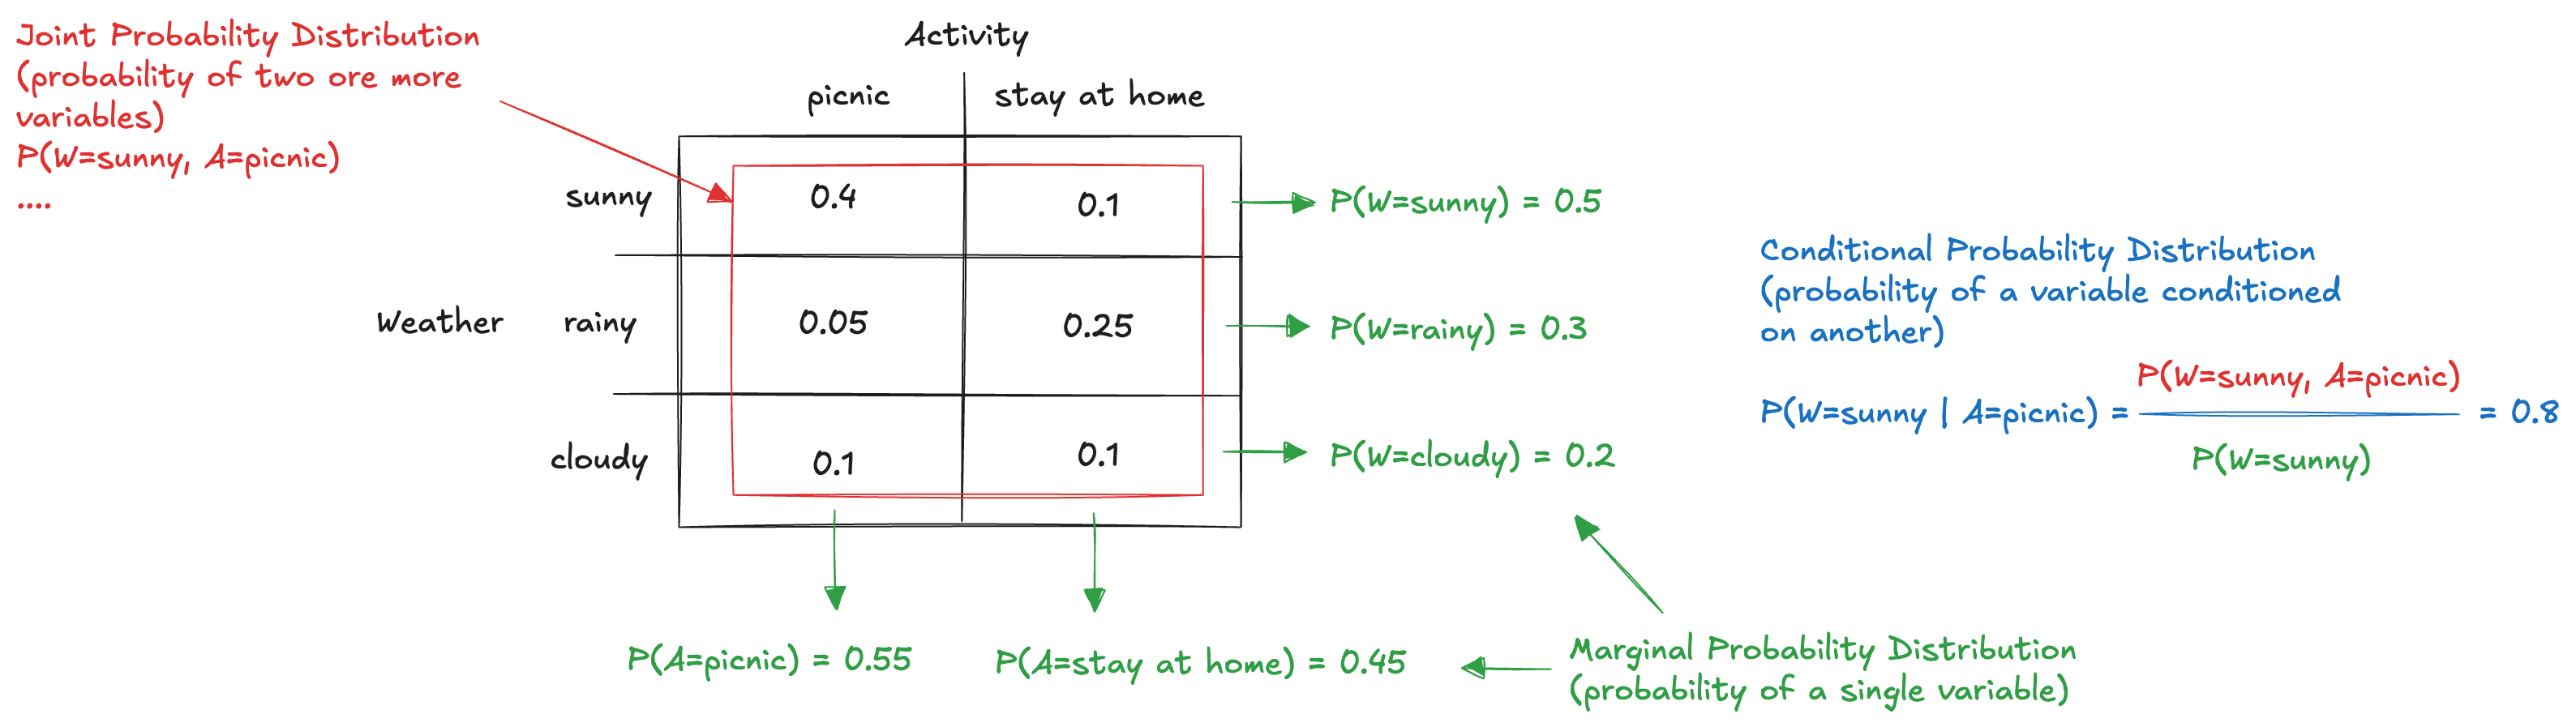

It is is the foundation for all probabilistic reasoning in a system. In practice, storing it directly for many variables is impossible because **its size grows exponentially**.

### Compact representation

We saw that **independence** and **conditional independence** relationships among variables can dramatically reduce the number of probabilities we need to specify to fully define the joint distribution. This is exactly what a **Bayesian network** does: it uses a compact data structure (a **directed acyclic graph (DAG)**) to represent the dependencies among variables in an efficient way. In a Bayesian network:
- Each node represents a random variable
- Directed links (arrows) indicate direct probabilistic influences between variables (parents)
- The graph contains no directed cycles, so we cannot return to the same node by following the arrows
- Each node is annotated with quantitative probability information: specifically, it has a conditional probability distribution that specifies how the variable depends on its parents in the graph

The **topology of the network** (the arrangement of nodes and arrows) defines the **conditional independence relationships** that hold within the domain.Intuitively, an arrow from node X to node Y means that X directly influences Y; this implies that causes should be modeled as parents of their effects. Identifying these direct influences is often straightforward for a domain expert.

Once the network structure is established, each variable must be assigned **local probability information** in the form of a conditional probability distribution given its parents. Together, the network topology and these local conditional distributions fully specify the joint probability distribution over all variables in the domain.

We can write a Python class to represent a node:

In [3]:
class Node:
    def __init__(self, name, parents, cpt):
        self.name = name
        self.parents = parents
        self.cpt = cpt

    def p(self, value, parents):
        return self.cpt[parents][value]

And the network itself can be represented as a list of nodes:

In [4]:
class BayesianNetwork:
    def __init__(self, nodes):
        self.nodes = nodes

To better understand how this type of structure works, consider a classic example: suppose you have a new alarm system installed in your home. It is fairly reliable at detecting a burglary but can occasionally be triggered by minor earthquakes. You also have two neighbors, John and Mary, who have promised to call you at work if they hear the alarm. John almost always calls when he hears the alarm, but he sometimes mistakes other sounds, like the telephone ringing, and calls by accident. Mary, on the other hand, often plays loud music and sometimes doesn’t hear the alarm at all. Given the evidence of who has or has not called, we would like to estimate the probability that a burglary has occurred. 

We can model this situation using the following random variables:
- Burglary: whether a burglary has occurred
- Earthquake: whether an earthquake has occurred
- Alarm: whether the alarm has gone off
- JohnCalls: whether John has called
- MaryCalls: whether Mary has called

A Bayes net for this domain can be: 

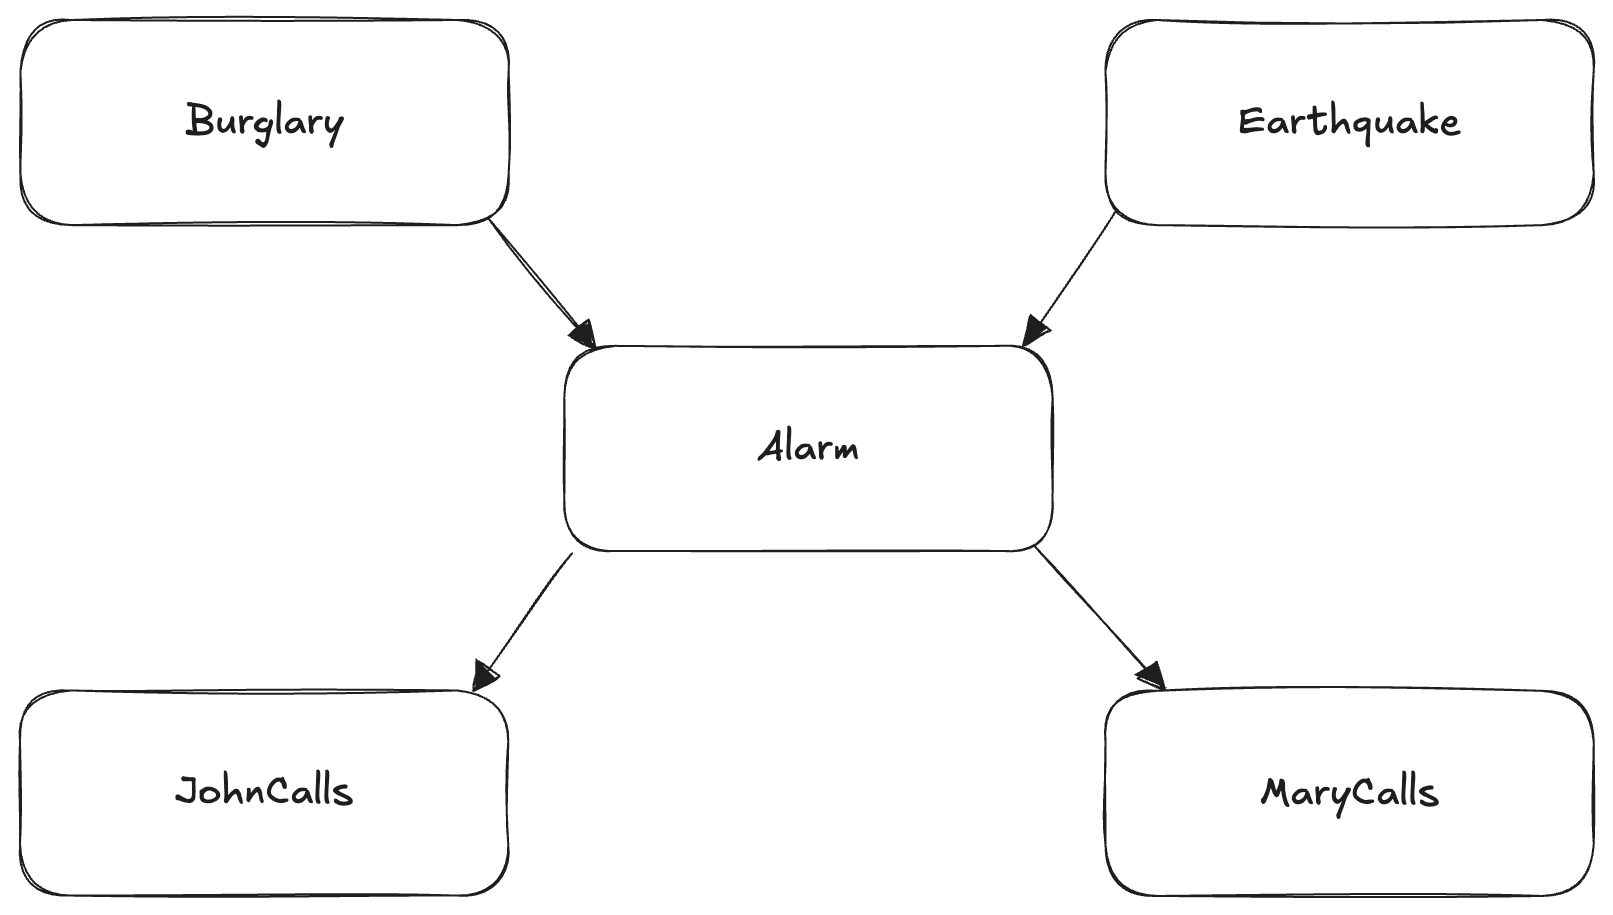

The network structure shows that both a burglary and an earthquake directly influence the probability that the alarm will sound, while whether John and Mary call depends only on whether they hear the alarm. This structure reflects our assumptions that John and Mary cannot directly detect a burglary or a minor earthquake, and that they make their calls independently without consulting each other.

The local probability information attached to each node takes the form
of a **conditional probability table (CPT)** (for discrete variables, other representations should be used for continuous variables). Each row in a CPT contains the conditional probability of each node value for a **conditioning case**. A conditioning case is just a possible combination of values for the parent nodes (a miniature possible world). Each row must sum to 1, because the entries represent an exhaustive set of cases for the variable. Root nodes (with no parents) have only one row, representing the prior probabilities of each possible value of the variable. In the example, we might have the following conditional probability tables:

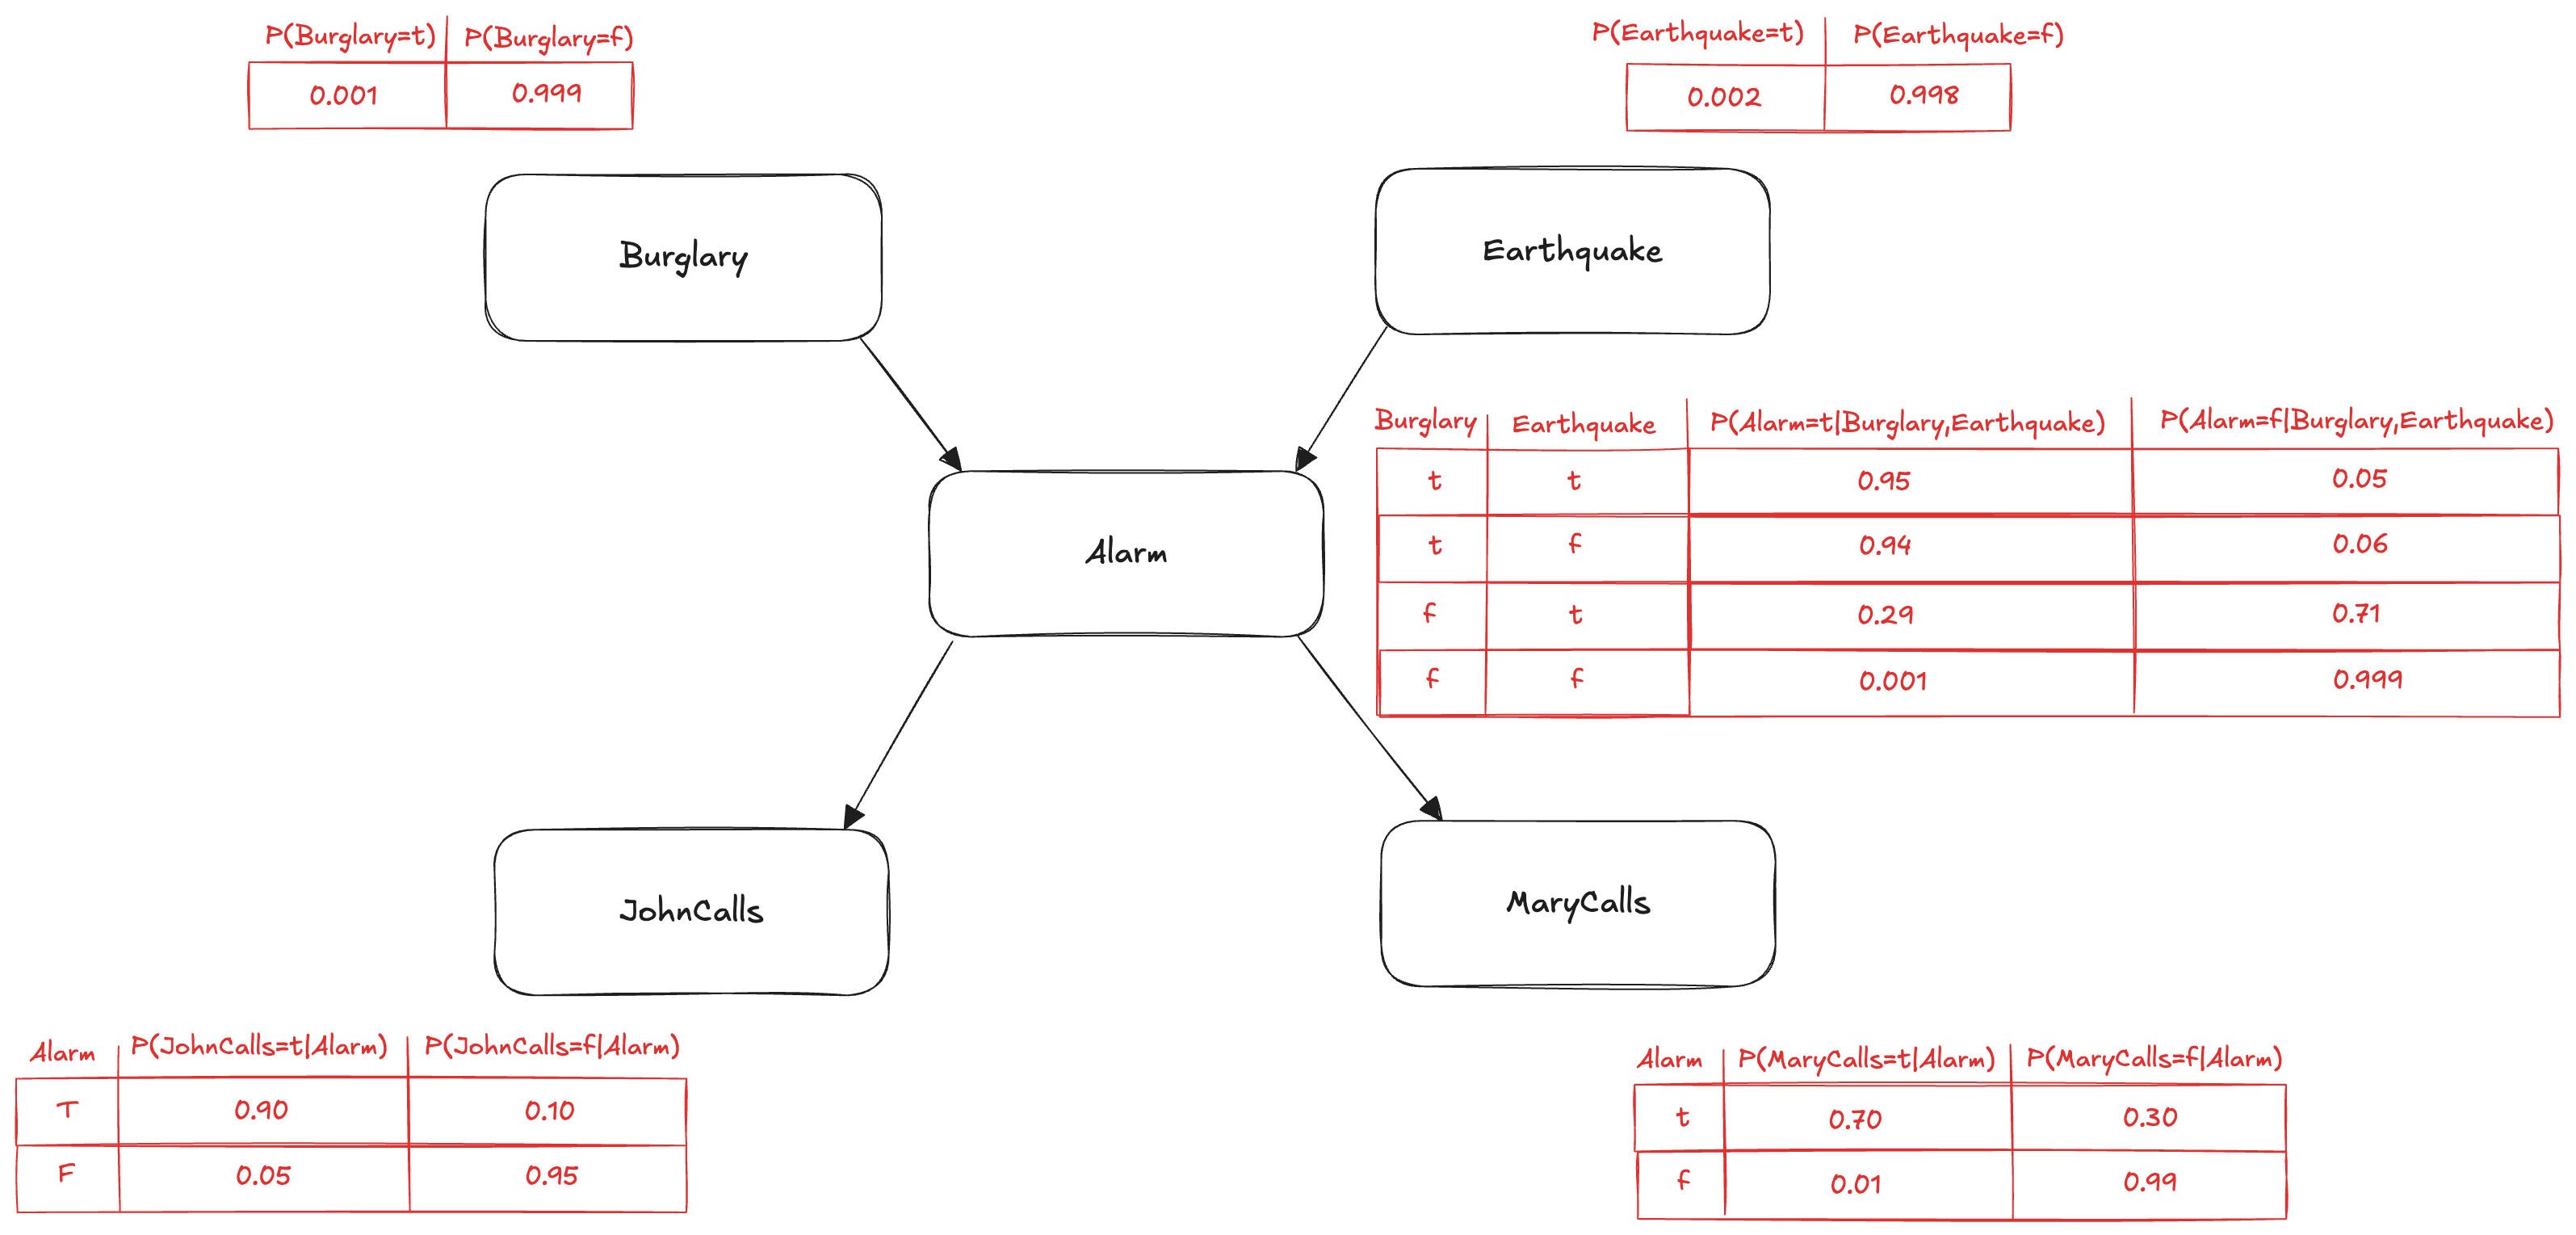

We can implement this network usgin our Python implementation. First we create the nodes:

In [5]:
burglary = Node('Burglary', [], {
    (): {True: 0.001, False: 0.999}
})

In [6]:
earthquake = Node('Earthquake', [], {
    (): {True: 0.002, False: 0.998}
})

In [7]:
alarm = Node('Alarm', ['Burglary', 'Earthquake'], {
    (True, True):  {True: 0.95, False: 0.05},
    (True, False): {True: 0.94, False: 0.06},
    (False, True): {True: 0.29, False: 0.71},
    (False, False):{True: 0.001, False: 0.999}
})

In [8]:
johncalls = Node('JohnCalls', ['Alarm'], {
    (True,):  {True: 0.90, False: 0.10},
    (False,): {True: 0.05, False: 0.95}
})

In [9]:
marycalls = Node('MaryCalls', ['Alarm'], {
    (True,):  {True: 0.70, False: 0.30},
    (False,): {True: 0.01, False: 0.99}
})

And the we add them to the network:

In [10]:
earthquake_net = BayesianNetwork({
    'Burglary': burglary,
    'Earthquake': earthquake,
    'Alarm': alarm,
    'JohnCalls': johncalls,
    'MaryCalls': marycalls
})

We can write a support function to show the network:

In [11]:
def print_bayes_net(bn):
    print("Bayesian Network Structure:")
    for var, node in bn.nodes.items():
        parents = ', '.join(node.parents) if node.parents else 'None'
        print(f" - Node: {var}")
        print(f"   Parents: {parents}")
        for k, v in node.cpt.items():
            parents_str = ', '.join(str(p) for p in k) if k else 'None'
            if isinstance(v, dict):
                for val, prob in v.items():
                    print(f"     P({var}={val} | {parents_str}) = {prob:.3f}")
            else:
                # fallback for simple single-float CPTs
                print(f"     P({var}=True | {parents_str}) = {v:.3f}")
                print(f"     P({var}=False | {parents_str}) = {1 - v:.3f}")
    print()

In [12]:
print_bayes_net(earthquake_net)

Bayesian Network Structure:
 - Node: Burglary
   Parents: None
     P(Burglary=True | None) = 0.001
     P(Burglary=False | None) = 0.999
 - Node: Earthquake
   Parents: None
     P(Earthquake=True | None) = 0.002
     P(Earthquake=False | None) = 0.998
 - Node: Alarm
   Parents: Burglary, Earthquake
     P(Alarm=True | True, True) = 0.950
     P(Alarm=False | True, True) = 0.050
     P(Alarm=True | True, False) = 0.940
     P(Alarm=False | True, False) = 0.060
     P(Alarm=True | False, True) = 0.290
     P(Alarm=False | False, True) = 0.710
     P(Alarm=True | False, False) = 0.001
     P(Alarm=False | False, False) = 0.999
 - Node: JohnCalls
   Parents: Alarm
     P(JohnCalls=True | True) = 0.900
     P(JohnCalls=False | True) = 0.100
     P(JohnCalls=True | False) = 0.050
     P(JohnCalls=False | False) = 0.950
 - Node: MaryCalls
   Parents: Alarm
     P(MaryCalls=True | True) = 0.700
     P(MaryCalls=False | True) = 0.300
     P(MaryCalls=True | False) = 0.010
     P(MaryCalls=Fal

Notice that the network does not include nodes for factors such as Mary listening to loud music or John mistaking the telephone ringing for the alarm. Instead, these influences are captured by the uncertainty in the links from Alarm to JohnCalls and MaryCalls. This reflects both **laziness** and **ignorance** at work: it would be impractical to identify and model every possible cause that might affect whether they call, and we often have no realistic way to gather such detailed information anyway. The probabilities in the network effectively summarize a potentially infinite variety of situations. For example, the alarm might fail due to high humidity, a power outage, a dead battery, or even a mouse jammed inside the bell. Similarly, John or Mary might fail to call because they are out to lunch, on vacation, momentarily deaf, or distracted by a passing helicopter. By summarizing all these possibilities in a compact form, a relatively simple model can still cope, at least approximately, with the complexity of the real world. The fact that each parameter of the
network has a precise meaning in terms of only a small set of variables is crucially important for robustness and ease of specification of the models.

### Computing Joint probabilities

We need to consider how the joint probaility distribution can be computed from a Bayesian network. Suppose we have n variables in the network:

$\displaystyle X_1, X_2, \ldots, X_n$

A generic entry in the joint distribution table would look like this:

$\displaystyle P(X_1 = x_1, X_2 = x_2, \ldots, X_n = x_n)$

Considering the structure of the network, we can rewrite this joint probability in terms of the conditional probabilities of each variable given its parents:

$\displaystyle P(X_1 = x_1, X_2 = x_2, \ldots, X_n = x_n) = \prod_{i=1}^{n} P(X_i = x_i \,|\, \text{Parents}(X_i))$

Thus, each entry in the joint probability distribution can be computed as the product of the relevant terms from the local conditional distributions defined in the Bayesian network. We can implement this in Python by defining a method that computes the joint probability for a given assignment of values to the variables in the network:

In [13]:
def full_joint_prob(bn, assignment):
    prob = 1.0
    for var_name, node in bn.nodes.items():
        parent_values = tuple(assignment[parent] for parent in node.parents)
        cpt_entry = node.cpt[parent_values]
        
        if isinstance(cpt_entry, dict):
            # Fully explicit CPT: {True: p1, False: p2}
            prob *= cpt_entry[assignment[var_name]]
        else:
            # Implicit: single P(True)
            prob *= cpt_entry if assignment[var_name] else 1 - cpt_entry

    return prob

For example, suppose we want to calculate the probability that the alarm goes on even though there is neither a burglary nor an earthquake, and that both John and Mary call. To find this probability, we simply multiply the appropriate probabilities from each local conditional distribution:

$\displaystyle P(A = t, B = f, E = f, J = t, M = t) = P(A = t \,|\, B = f, E = f) \cdot P(B = f) \cdot P(E = f) \cdot P(J = t \,|\, A = t) \cdot P(M = t \,|\, A = t) = 0.01 \cdot 0.999 \cdot 0.998 \cdot 0.90 \cdot 0.70 = 0.00628$

In [14]:
assignment = {
    'Burglary': False,
    'Earthquake': False,
    'Alarm': True,
    'JohnCalls': True,
    'MaryCalls': True
}

p_joint = full_joint_prob(earthquake_net, assignment)

print(f"P(A=True, B=False, E=False, J=True, M=True) = {p_joint:.6f}")

P(A=True, B=False, E=False, J=True, M=True) = 0.000628


Since the full joint distribution contains all the information needed to answer any probabilistic query about the domain, and a Bayesian network is simply a compact representation of that joint distribution, **the network can also be used to answer any query**. This is done by summing over the relevant entries in the joint distribution, with each entry computed as the product of the appropriate local conditional probabilities.

### Inference

The basic task for any probabilistic system is to compute the posterior probability distribution for a **query variable** X

$\displaystyle X = x$

given some observed event, usually, some assignment of values to a set of **evidence variables**:

$\displaystyle Ev = \{Ev_1 = ev_1, Ev_2 = ev_2, \ldots, Ev_m = ev_m\}$

The other variables in the network are called **hidden variables**, since they are not observed:

$\displaystyle Y = \{Y_1, Y_2, \ldots, Y_\ell\}$

Thus, the complete set of variables is:

$\displaystyle V = {X}, Ev, Y = \{X, Ev_1, Ev_2, \ldots, Ev_m, Y_1, Y_2, \ldots, Y_\ell\}$

A typical query asks for the posterior probability distribution:

$\displaystyle P(X=x \,|\, Ev=ev)$

In the burglary network, we might observe the event in whic John and Mery both called, and we want to know the probability of a burglary having occurred:

$\displaystyle P(B = true \,|\, J = true, M = true)$

#### By enumeration

The simplest way to compute the posterior probability is to use **enumeration**. This method involves using marginalization to summing over all possible values of the hidden variables, while conditioning on the evidence E. In order to simplify the notation, we will write the value of a variable "a" instead the complete assignmen "A=a". The posterior probability can be computed as:

$\displaystyle P(x \,|\, ev) = \frac{P(x, ev)}{P(ev)} = \frac{\sum_{y} P(x, ev, y)}{P(ev)}$

Each term in the summation is computed from the joint probability distribution specified by the Bayesian network:

$\displaystyle P(x, ev, y) = \prod_{i=1}^{l+m+1} P(v_i \,|\, \text{parents}(v_i))$

The denominator is obtained by marginalizing the joint distribution over all possible values of the query and hidden variables.

$\displaystyle P(ev) = \sum_{x,y} P(ev, x, y)$

This is known as the **normalization constant**, ensuring that the posterior sums to 1, with its reciprocal represented by $\alpha$.

Therefore, to answer a query using a Bayesian network, we calculate sums of products of the conditional probabilities defined by the network:

$\displaystyle P(x \,|\, ev) = \alpha \sum_{y} P(x, ev, y)$

Considering the example, the hidden variables are the earthquake and alarm. In the notaion we represent true value using the name of the variable, and false value using the negation of the variable name:

$\displaystyle P(ev) = P(J, M) = $     
$\displaystyle P(J, M, \lnot E, \lnot A, \lnot B) + $      
$\displaystyle P(J, M, \lnot E, \lnot A, B) + $      
$\displaystyle P(J, M, \lnot E, A, \lnot B) + $      
$\displaystyle P(J, M, \lnot E, A, B) + $      
$\displaystyle P(J, M, E, \lnot A, \lnot B) + $      
$\displaystyle P(J, M, E, \lnot A, B) + $      
$\displaystyle P(J, M, E, A, \lnot B) + $      
$\displaystyle P(J, M, E, A, B)$

Using the information from the network we can substitute the joint probabilities with the products of the conditional probabilities. We do this using the code already written to compute the joint probability:

In [15]:
denominator = 0

# Loop over all possible values of E, A, B
for Earthquake in [False, True]:
    for Alarm in [False, True]:
        for Burglary in [False, True]:
            assignment = {
                'Burglary': Burglary,
                'Earthquake': Earthquake,
                'Alarm': Alarm,
                'JohnCalls': True,
                'MaryCalls': True
            }
            denominator += full_joint_prob(earthquake_net, assignment)

The numerator term can be computed as follows:

$\displaystyle P(B, J, M) = $     
$\displaystyle P(B, J, M, \lnot E, \lnot A) + $       
$\displaystyle P(B, J, M, \lnot E, A) + $       
$\displaystyle P(B, J, M, E, \lnot A) + $       
$\displaystyle P(B, J, M, E, A)$

Again we can compute this using the joint probability distribution implementation:

In [16]:
numerator = 0
for Earthquake in [False, True]:
    for Alarm in [False, True]:
        assignment = {
            'Burglary': True,
            'Earthquake': Earthquake,
            'Alarm': Alarm,
            'JohnCalls': True,
            'MaryCalls': True
        }
        numerator += full_joint_prob(earthquake_net, assignment)

Finally, we can compute the posterior probability:

In [17]:
print(f"P(B=True, J=True, M=True) = {numerator / denominator:.6f}")

P(B=True, J=True, M=True) = 0.284172


That is, the chance of a burglary, given calls from both neighbors, is about 28%. 

In the worst case, where we have to sum out almost all the variables, there will be O(^2n) terms in the sum, each a product of O(n) probability values. A naive implementation would therefore have complexity O(n2^n):

In [18]:
import itertools

def enumeration(query_var, query_value, evidence, network):
    all_vars = set(network.nodes.keys())
    hidden_vars = list(all_vars - {query_var} - set(evidence.keys()))

    # Get possible values for query_var
    query_node = network.nodes[query_var]
    possible_query_values = list(next(iter(query_node.cpt.values())).keys())

    # Get possible values for hidden vars
    hidden_domains = []
    for var in hidden_vars:
        node = network.nodes[var]
        vals = list(next(iter(node.cpt.values())).keys())
        hidden_domains.append(vals)

    numerator = 0.0
    denominator = 0.0

    for hidden_values in itertools.product(*hidden_domains):
        assignment = dict(evidence)
        assignment[query_var] = query_value
        assignment.update(dict(zip(hidden_vars, hidden_values)))
        numerator += full_joint_prob(network, assignment)

    for hidden_values in itertools.product(*hidden_domains):
        for val in possible_query_values:
            assignment = dict(evidence)
            assignment[query_var] = val
            assignment.update(dict(zip(hidden_vars, hidden_values)))
            denominator += full_joint_prob(network, assignment)

    result = numerator / denominator if denominator > 0 else 0.0
    return result

We can apply the function to the example:

In [19]:
prob = enumeration(query_var='Burglary', query_value=True,
                   evidence={'JohnCalls': True, 'MaryCalls': True},
                   network=earthquake_net
)

print(f"P(Burglary=True | JohnCalls=True, MaryCalls=True) = {prob:.6f}")

P(Burglary=True | JohnCalls=True, MaryCalls=True) = 0.284172


## Reasoning patterns

One of the greatest strengths of Bayesian Networks is that they don’t just store probabilities, they also **capture how knowledge about one variable changes our beliefs about others**. This is possible because the graph structure tells us who depends on whom, and the conditional probability tables tell us how strong those dependencies are. Bayesian Networks naturally support three fundamental reasoning patterns:
- **Causal (predictive) reasoning**: from causes to effects
- **Evidential (diagnostic) reasoning**: from effects back to causes
- **Intercausal reasoning (explaining away)**: when different causes compete to explain the same observed effect

Understanding these reasoning patterns is essential for interpreting how new evidence reshapes our beliefs in a probabilistic model. To illustrate how they work in practice, we will use an example network that shows how a student’s knowledge and the difficulty of an exam influence the grade they receive, and how these factors together affect the probability of obtaining a strong recommendation letter.
 
The variables are:
- Knowledge (K): the level of knowledge the student has on the subject, which can be low (k0) or high (k1)
- Difficulty (D): the difficulty of the exam, which can be low (d0) or high (d1)
- Grade (G): the grade obtained in the exam, which can be A (g1), B (g2), or C (g3)
- Letter (L): the recomendation letter that can be obtained (l0) or not (l1)
- Standardized test (S): the result of the student on a standardized test, which can be low (s0) or high (s1)

The network structure is as follows:

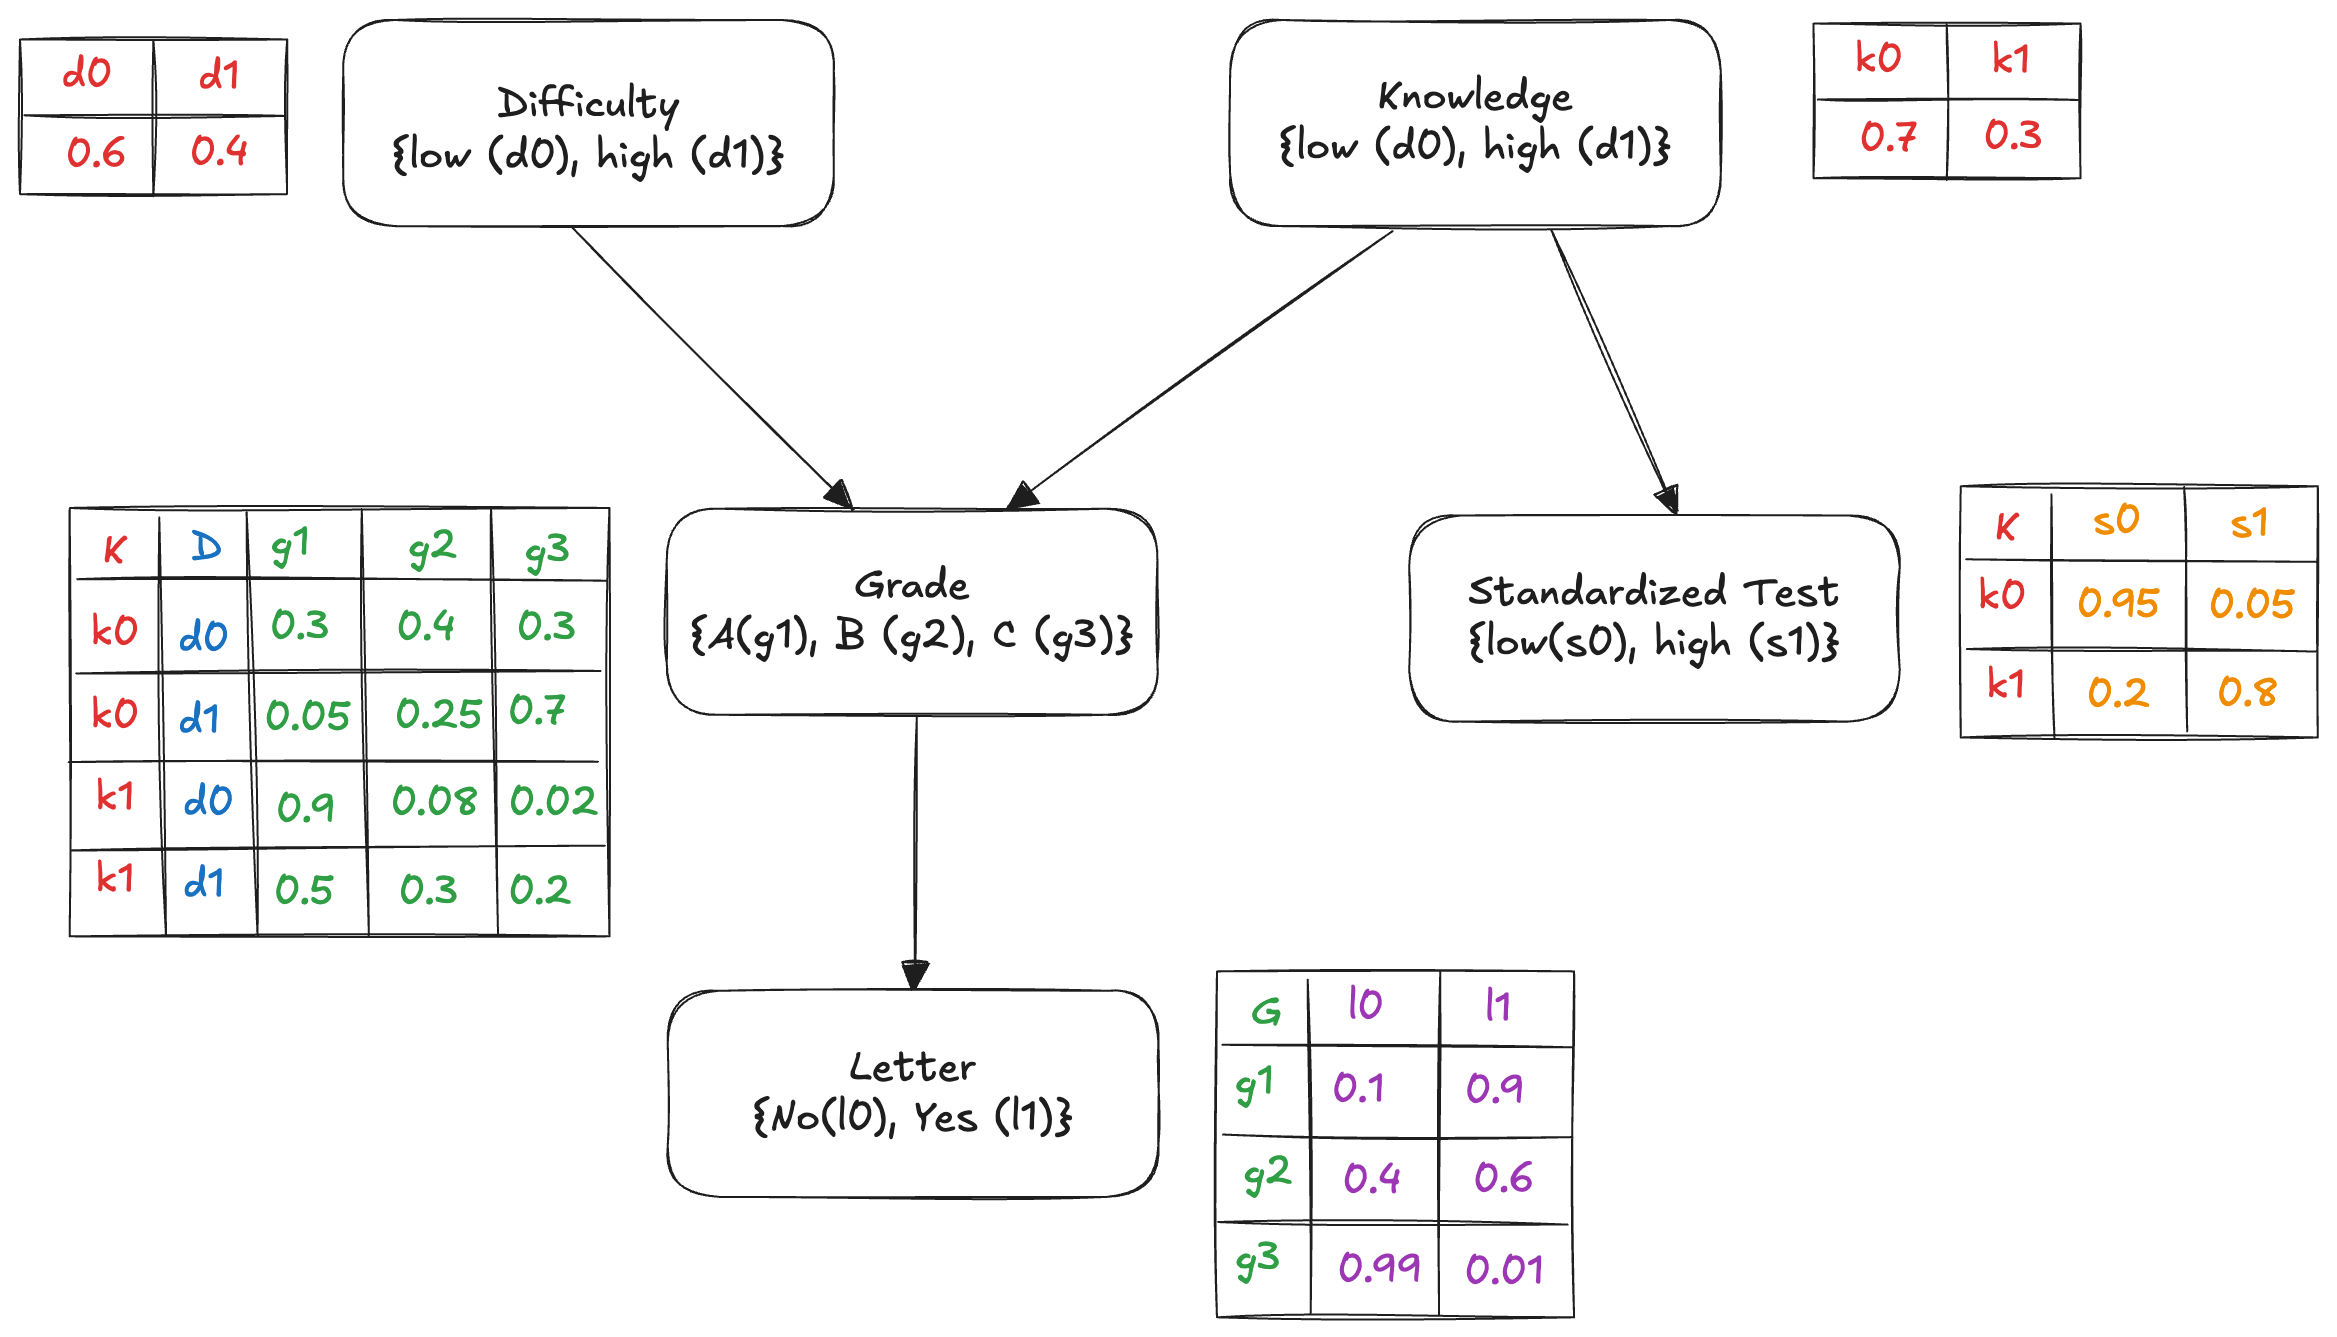

The chance of receiving a recommendation letter depends directly on the student’s grade, which itself is influenced by both the student’s knowledge and the difficulty of the exam. In contrast, the result of the standardized test depends only on the student’s knowledge:

$\displaystyle P(D, K, G, S, L) = P(D) P(K) P(G | D, K) P(S | K) P(L | G)$

We can implement this network in Python:

In [20]:
difficulty = Node(
    name='Difficulty',
    parents=[],
    cpt={
        (): {'d0': 0.6, 'd1': 0.4}
    }
)

knowledge = Node(
    name='Knowledge',
    parents=[],
    cpt={
        (): {'k0': 0.7, 'k1': 0.3}
    }
)


grade = Node(
    name='Grade',
    parents=['Knowledge', 'Difficulty'],
    cpt={
        ('k0', 'd0'): {'g1': 0.3, 'g2': 0.4, 'g3': 0.3},
        ('k0', 'd1'): {'g1': 0.05, 'g2': 0.25, 'g3': 0.7},
        ('k1', 'd0'): {'g1': 0.9, 'g2': 0.08, 'g3': 0.02},
        ('k1', 'd1'): {'g1': 0.5, 'g2': 0.3, 'g3': 0.2}
    }
)

letter = Node(
    name='Letter',
    parents=['Grade'],
    cpt={
        ('g1',): {'l0': 0.1, 'l1': 0.9},
        ('g2',): {'l0': 0.4, 'l1': 0.6},
        ('g3',): {'l0': 0.99, 'l1': 0.01}
    }
)

test = Node(
    name='StandardizedTest',
    parents=['Knowledge'],
    cpt={
        ('k0',): {'s0': 0.95, 's1': 0.05},
        ('k1',): {'s0': 0.2, 's1': 0.8}
    }
)

In [21]:
letter_net = BayesianNetwork({
    'Difficulty': difficulty,
    'Knowledge': knowledge,
    'Grade': grade,
    'Letter': letter,
    'Test': test
})

### Causal reasoning

Causal reasoning is reasoning in the same direction as the arrows in our Bayesian Network. It is the most intuitive form: "if I know the cause, what should I believe about the effect?". For example, we can ask what is the probbility of getting a recommendation letter:

In [22]:
prob = enumeration(query_var='Letter', query_value='l1',
                   evidence={},
                   network=letter_net
)

print(f"P(Letter=True) = {prob:.2f}")

P(Letter=True) = 0.50


How the level of student knowledge affects the likelihood of obtaining a strong recommendation letter:

In [23]:
prob = enumeration(query_var='Letter', query_value='l1',
                   evidence={'Knowledge': 'k0'},
                   network=letter_net)

print(f"P(Letter=True | Knowledge=k0) = {prob:.2f}")

P(Letter=True | Knowledge=k0) = 0.39


How does the outcome change when we factor in the difficulty of the exam?

In [24]:
prob = enumeration(query_var='Letter', query_value='l1',
                   evidence={'Knowledge': 'k0', 'Difficulty': 'd0'},
                   network=letter_net)  

print(f"P(Letter=True | Knowledge=k0, Difficulty=d0) = {prob:.2f}")  


P(Letter=True | Knowledge=k0, Difficulty=d0) = 0.51


Let's check this probability making the calculation and exploiting probability rules:

$\displaystyle P(l1 \,|\, k0, d0) = \frac{P(l1, k0, d0)}{P(k0, d0)} = $     

$\displaystyle = \frac{\sum_{g}{P(l1, k0, d0, g)}}{P(k0) P(d0)} = $

$\displaystyle = \frac{\sum_{g}{P(d0)P(k0)P(g|d0,k0)P(l1|g))}}{P(k0) P(d0)} = $

$\displaystyle = P(d0) P(k0) \frac{\sum_{g}{P(g|d0,k0)P(l1|g)}}{P(k0) P(d0)} = $

$\displaystyle = \sum_{g}{P(g|d0,k0)P(l1|g)}$

$\displaystyle = 0.3 * 0.9 + 0.4 * 06 + 0.3 * 0.01 = 0.513$ 

This forward flow is called predictive reasoning, because you are predicting possible consequences of known causes.

### Evidential reasoning

**Evidential reasoning**, sometimes called **diagnostic reasoning**, is the process of reasoning backward, from an observed effect to possible causes. It answers questions like "if I know the effect, what should I believe about the cause?". 

For example, if we know the student received a C (g3), how does this evidence update our belief about the exam’s difficulty and the student’s knowledge of the material?

In [25]:
prob = enumeration(query_var='Difficulty', query_value='d1',
                   evidence={'Grade': 'g3'},
                   network=letter_net)  

print(f"P(Difficulty = d1 | Grade = g3) = {prob:.2f}")

P(Difficulty = d1 | Grade = g3) = 0.63


In [26]:
prob = enumeration(query_var='Knowledge', query_value='k1',
                   evidence={'Grade': 'g3'},
                   network=letter_net)  

print(f"P(Knowledge = k1 | Grade = g3) = {prob:.2f}")

P(Knowledge = k1 | Grade = g3) = 0.08


Let's check the second value:

$\displaystyle P(k1 | g3) = \frac{P(k1, g3)}{P(g3)}$

$\displaystyle = \frac{\sum_d P(d, k1, g3)}{P(g3)}$

$\displaystyle = \frac{\sum_d P(d) P(k1) P(g3|d, k1)}{P(g3)}$

$\displaystyle = \frac{(0.6 * 0.3 0.02) + (0.4 * 0.2 * 0.2)}{0.350} \approx 0.079$

### Intercausal reasoning

**Intercausal reasoning** happens when two or more independent causes can each produce the same effect. If we know the effect, the causes become dependent: they "compete" to explain it.

For example, suppose we know that a student received an A. This makes us believe that the student’s knowledge is probably high:

In [27]:
prob = enumeration(query_var='Knowledge', query_value='k1',
                   evidence={'Grade': 'g1'},
                   network=letter_net) 

print(f"P(Knowledge = k1 | Grade = g1) = {prob:.2f}")

P(Knowledge = k1 | Grade = g1) = 0.61


or that the course difficulty was likely low: 

In [28]:
prob = enumeration(query_var='Difficulty', query_value='d0',
                   evidence={'Grade': 'g1'},
                   network=letter_net) 

print(f"P(Difficulty = d0 | Grade = g1) = {prob:.2f}")

P(Difficulty = d0 | Grade = g1) = 0.80


These two factors compete because they both help explain the good grade. If we then find out that the course was indeed easy, we may lower our belief that the student’s knowledge was high, since the low difficulty already accounts for the strong performance:

In [29]:
prob = enumeration(query_var='Knowledge', query_value='k1',
                   evidence={'Grade': 'g1', 'Difficulty': 'd0'},
                   network=letter_net) 

print(f"P(Knowledge = k1 | Grade = g1, Difficulty = d0) = {prob:.2f}")

P(Knowledge = k1 | Grade = g1, Difficulty = d0) = 0.56


Instead if we find out that the difficulty was high, we may raise our belief that the student’s knowledge was high, since the difficult course makes it less likely that the student would have received an A without strong knowledge:

In [30]:
prob = enumeration(query_var='Knowledge', query_value='k1',
                   evidence={'Grade': 'g1', 'Difficulty': 'd1'},
                   network=letter_net) 

print(f"P(Knowledge = k1 | Grade = g1, Difficulty = d1) = {prob:.2f}")

P(Knowledge = k1 | Grade = g1, Difficulty = d1) = 0.81


As another example, suppose now that the student earns a C (g3) but achieves a high (s1) score on the standardized test. How does this affect the posterior probability that the course is challenging?

In [31]:
prob = enumeration(query_var='Difficulty', query_value='d1',
                   evidence={'Grade': 'g3'},
                   network=letter_net) 

print(f"P(Difficulty = k1 | Grade = g3) = {prob:.2f}")

P(Difficulty = k1 | Grade = g3) = 0.63


In [32]:
prob = enumeration(query_var='Difficulty', query_value='d1',
                   evidence={'Grade': 'g3', 'Test': 's1'},
                   network=letter_net) 

print(f"P(Difficulty = d1 | Grade = g3, Test = s1) = {prob:.2f}")

P(Difficulty = d1 | Grade = g3, Test = s1) = 0.76


And what happes to the posterior probability that the student’s knowledge is high?

In [33]:
prob = enumeration(query_var='Knowledge', query_value='k1',
                   evidence={'Grade': 'g3'},
                   network=letter_net) 
print(f"P(Knowledge = k1 | Grade = g3) = {prob:.2f}")

P(Knowledge = k1 | Grade = g3) = 0.08


In [34]:
prob = enumeration(query_var='Knowledge', query_value='k1',
                   evidence={'Grade': 'g3', 'Test': 's1'},
                   network=letter_net) 

print(f"P(Knowledge = k1 | Grade = g3, Test = s1) = {prob:.2f}")    

P(Knowledge = k1 | Grade = g3, Test = s1) = 0.58


### Dependencies

In general,  a variable X can influence variable Y if there is a **direct causal link**, an **evidential link**, or **an indirect chain** connecting them. However if X and Y both point into a common child (a **v-structure**) without any other evidence, they remain independent and X cannot influence Y:

| Structure                  | Can X influence Y?         |
|----------------------------|----------------------------|
| X -> Y                     | Yes (causal)               |
| X <- Y                     | Yes (evidential)           |
| X -> W -> Y                | Yes (causal chain)         |
| X <- W <- Y                | Yes (evidential)           |
| X <- W -> Y                | Yes (fork)                 |
| X -> W <- Y (v-structure)  | No  (collider)             |

We can define **active trail** a path through which information can flow between variables given the current evidence, meaning those variables can still influence each other under the conditional independence rules. A trail:

$\displaystyle X_1 \to X_2 \to X_3 \to \ldots \to X_n$

is active if it does not contain any v-structures.

If we have some evidence E, things get more complicated. Of course if X is directly connected to Y, the influece is still there. However, if X and Y are connected through a common child W, the influence can be blocked by the evidence E. In this case, we say that the evidence **can block the trail** between X and Y:

| Structure            | Can X influence Y given E? | W $\notin$ E | W $\in$ E |
|----------------------|----------------------------|--------------|-----------|
| X → W → Y            |                            |    Yes       |    No     |
| X ← W ← Y            |                            |    Yes       |    No     |
| X ← W → Y (fork)     |                            |    Yes       |    No     |
| X → W ← Y (collider) |                            |   No/Yes     |    Yes    |

In a chain or a fork, the intermediate node passes the flow of influence. So if you observe W, it blocks the influence, because we have "fixed" that uncertainty.

In the case of a collider, W is a common effect of X and Y. If we don’t know anything about W (or its descendants), then knowing X tells us nothing about Y. They are conditionally independent because we haven’t looked at their shared effect. However, if we observe W (or any of its descendants), we now know something about the effect and this creates a dependence between the causes. We have No/Yes because if we do not observe W but we  observe a descendant of W, that activates the path through the collider.

## Approximate inference

In a Bayesian Network, exact inference can be computationally expensive, even NP-hard, when the network is large or densely connected. So instead, we often use **approximate inference**, which gives us a good estimate of the desired probabilities by using sampling methods. Instead of summing over an exponential number of possible worlds, we generate samples (possible worlds) that are consistent with the network structure and conditional probabilities. Then, we estimate probabilities by looking at the relative frequencies in these samples.

We play out possible worlds according to the generative story described by our Bayesian Network. It defines how the world works: each node has a probability of being true or false, conditioned on its parents. If we sample each variable in topological order (parents first, then children), we can generate an entire world that’s internally consistent with the joint distribution. The following code generate a sample from the network:

In [39]:
import random

def create_sample(network):
    sample = {}

    for var_name, node in network.nodes.items():
    
        # Get parent values
        parent_values = tuple(sample[parent] for parent in node.parents)
        outcome_probs = node.cpt[parent_values]

        # Sample from the categorical distribution
        r = random.random()
        cumulative = 0.0
        for outcome, prob in outcome_probs.items():
            cumulative += prob
            if r < cumulative:
                sample[var_name] = outcome
                break
        else:
            # In case of numerical precision issues
            sample[var_name] = outcome

    return sample

For example, we can generate a sample from the student network:

In [40]:
sample = create_sample(letter_net)
print("Sample", sample)

Sample {'Difficulty': 'd1', 'Knowledge': 'k1', 'Grade': 'g1', 'Letter': 'l1', 'Test': 's1'}


Each sample is like rolling dice according to each conditional probability distribution defined in the network. After generating thousands of such samples, we can approximate any probability:

In [41]:
def sampling(query_var, query_value, evidence, network, num_samples=1000):

    matches_evidence = 0
    matches_query_and_evidence = 0

    for _ in range(num_samples):
        sample = create_sample(network)

        # Check if sample matches the evidence
        if all(sample[var] == val for var, val in evidence.items()):
            matches_evidence += 1
            if sample[query_var] == query_value:
                matches_query_and_evidence += 1

    if matches_evidence == 0:
        return 0.0  # Avoid division by zero

    return matches_query_and_evidence / matches_evidence

For example, we can see how the quality of the answer changes as we increase the number of samples. We can consider the probability of getting a recommendation letter given that the student has low knowledge (we already know that the result is 0.39):

In [42]:
prob = sampling(query_var='Letter', query_value='l1',
                   evidence={'Knowledge': 'k0'},
                   network=letter_net,
                   num_samples=10000)

print(f"P(Letter=l1 | Knowledge=k0) = {prob:.2f}")


P(Letter=l1 | Knowledge=k0) = 0.38


If the evidence we’re conditioning on is a relatively rare event, then many samples will be discarded because they don’t match it. This can become quite inefficient, since we may need to generate a very large number of samples just to keep a few that are useful.